# Módulo 07: Introdução à Séries Temporais
>
> [Universidade Federal do Ceará (UFC)](https://www.ufc.br/)\
> [Departamento de Computação (DC)](https://dc.ufc.br/pt/)\
> [Capacitação Técnica e Empreendedora em IA (CTE-IA)](https://www.cteia.dc.ufc.br/)\
> Fase I: Capacitação Teórica de IA\
> Disciplina: Programação para Ciência de Dados (60h)\
> Professor: [Lincoln S. Rocha](http://lattes.cnpq.br/0656977742590515)\
> E-mail: <lincoln@dc.ufc.br>
>

A análise de séries temporais em Python envolve o trabalho com pontos de dados indexados em ordem cronológica para identificar padrões, tendências e fazer previsões sobre valores futuros. O Python oferece um rico ecossistema de bibliotecas e ferramentas para esse propósito. Neste módulo veremos como usar o Pandas para trabalhar com dados de séries temporais. Este módulo cobrirá o seguinte conteúdo:

- Tipos e Ferramentas de Dados de Data e Hora
- Noções Básicas de Séries Temporais
- Intervalos de Datas, Frequências e Deslocamento
- Manipulação de Fusos Horários
- Períodos e Aritmética de Períodos
- Reamostragem e Conversão de Frequência
- Funções de Janela Móvel

## 7.1. Introdução

Dados de séries temporais são uma forma importante de dados estruturados em diversas áreas, como finanças, economia, ecologia, neurociência e física. Qualquer coisa que seja registrada repetidamente em vários pontos no tempo forma uma série temporal. Muitas séries temporais têm *frequência fixa*, ou seja, os pontos de dados ocorrem em intervalos regulares de acordo com alguma regra, como a cada 15 segundos, a cada 5 minutos ou uma vez por mês. As séries temporais também podem ser *irregulares*, sem uma unidade de tempo fixa ou deslocamento entre as unidades. A forma como você marca e se refere aos dados de séries temporais depende da aplicação, e você pode ter uma das seguintes opções:

- *Timestamps* (carimbos de tempo): Instantes específicos no tempo.

- Períodos fixos: Como todo o mês de janeiro de 2020 ou todo o ano de 2025.

- Intervalos de tempo: Indicados por um carimbo de data/hora de início e um de fim. Períodos podem ser considerados casos especiais  de intervalos.

- Tempo de experimento ou tempo decorrido: Cada registro de data e hora é uma medida de tempo relativa a um horário de início específico (por exemplo, o diâmetro de um biscoito assando a cada segundo desde que foi colocado no forno), começando em 0.

Neste módulo, iremos nos concentrar principalmente em séries temporais das três primeiras categorias, embora muitas das técnicas possam ser aplicadas a séries temporais experimentais, onde o índice pode ser um número inteiro ou de ponto flutuante indicando o tempo decorrido desde o início do experimento. O tipo mais simples de série temporal é indexado por carimbo de data/hora.

O Pandas oferece diversas ferramentas e algoritmos integrados para séries temporais. Você pode trabalhar de forma eficiente com grandes séries temporais, segmentá-las, agregá-las e reamostrá-las, tanto em séries com frequência irregular quanto fixa. Algumas dessas ferramentas são úteis para aplicações financeiras e econômicas, mas você certamente também pode usá-las para analisar dados de logs de servidores.

## 7.2. Tipos e Ferramentas de Dados de Data e Hora

A biblioteca padrão do Python inclui tipos de dados para data e hora, bem como funcionalidades relacionadas a calendários. Os módulos `datetime`, `time` e `calendar` são os principais pontos de partida. O tipo `datetime.datetime`, ou simplesmente `datetime`, é amplamente utilizado:

In [3]:
from datetime import datetime
now = datetime.now()
now

datetime.datetime(2025, 11, 22, 13, 8, 39, 292721)

In [4]:
now.year, now.month, now.day

(2025, 11, 22)

O objeto `datetime` armazena a data e a hora com precisão de microssegundos. O parâmetro `datetime.timedelta`, ou simplesmente `timedelta`, representa a diferença temporal entre dois objetos `datetime`:

In [5]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)
delta

datetime.timedelta(days=926, seconds=56700)

In [6]:
delta.days

926

In [7]:
delta.seconds

56700

Você pode adicionar (ou subtrair) um valor de `timedelta` ou um múltiplo dele a um objeto `datetime` para gerar um novo objeto deslocado:

In [8]:
from datetime import timedelta

start = datetime(2011, 1, 7)
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

In [9]:
start - 2 * timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

A tabela abaixo resume os tipos de dados no módulo `datetime`. Embora este módulo se concentre principalmente nos tipos de dados do Pandas e na manipulação de séries temporais de nível superior, você pode encontrar tipos baseados em `datetime` em muitos outros lugares no Python.

| Tipo | Descrição |
|-------|------------|
| `date` | Armazena uma data de calendário (ano, mês e dia) usando o calendário gregoriano. |
| `time` | Armazena o horário do dia em horas, minutos, segundos e microssegundos. |
| `datetime` | Armazena tanto a data quanto o horário. |
| `timedelta` | Representa a diferença entre dois valores `datetime` (em dias, segundos e microssegundos). |
| `tzinfo` | Tipo base para armazenar informações de fuso horário. |

Você pode formatar objetos `datetime` e objetos `Timestamp` do Pandas (que apresentaremos mais adiante) como strings usando o método `str` ou `strftime`, passando uma especificação de formato:

In [10]:
stamp = datetime(2011, 1, 3)
str(stamp)

'2011-01-03 00:00:00'

In [11]:
stamp.strftime("%Y-%m-%d")

'2011-01-03'

Consulte a tabela abaixo para obter uma lista completa dos códigos de formato.

| Tipo | Descrição |
|-------|------------|
| `%Y` | Ano com quatro dígitos. |
| `%y` | Ano com dois dígitos. |
| `%m` | Mês com dois dígitos (de 01 a 12). |
| `%d` | Dia com dois dígitos (de 01 a 31). |
| `%H` | Hora (formato 24 horas) de 00 a 23. |
| `%I` | Hora (formato 12 horas) de 01 a 12. |
| `%M` | Minuto com dois dígitos (de 00 a 59). |
| `%S` | Segundo (de 00 a 61 — valores 60 e 61 são usados para segundos bissextos). |
| `%f` | Microssegundos como número inteiro, preenchido com zeros (de 000000 a 999999). |
| `%j` | Dia do ano como número inteiro preenchido com zeros (de 001 a 336). |
| `%w` | Dia da semana como número inteiro (0 para domingo, até 6). |
| `%u` | Dia da semana como número inteiro iniciando em 1, onde 1 representa segunda-feira. |
| `%U` | Número da semana do ano (de 00 a 53); domingo é considerado o primeiro dia da semana e os dias antes do primeiro domingo são parte da “semana 0”. |
| `%W` | Número da semana do ano (de 00 a 53); segunda-feira é considerada o primeiro dia da semana e os dias antes da primeira segunda são parte da “semana 0”. |
| `%z` | Deslocamento do fuso horário UTC no formato `+HHMM` ou `-HHMM`; vazio se não houver fuso horário. |
| `%Z` | Nome do fuso horário como string, ou string vazia se não houver fuso horário. |
| `%F` | Atalho para `%Y-%m-%d` (exemplo: `2012-04-18`). |
| `%D` | Atalho para `%m/%d/%y` (exemplo: `04/18/12`). |

Você pode usar muitos dos mesmos códigos de formato para converter strings em datas usando `datetime.strptime` (mas alguns códigos, como `%F`, não podem ser usados):

In [12]:
value = "2011-01-03"
datetime.strptime(value,"%Y-%m-%d")

datetime.datetime(2011, 1, 3, 0, 0)

In [13]:
datestrs = ["7/6/2011", "8/6/2011"]
[datetime.strptime(x, "%m/%d/%Y") for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

`datetime.strptime` é uma forma de analisar uma data com um formato conhecido.

O Pandas é geralmente orientado para trabalhar com arrays de datas, seja como índice de eixo ou coluna em um `DataFrame`. O método `pandas.to_datetime` analisa diversos tipos de representações de data. Formatos de data padrão, como ISO 8601, podem ser analisados ​​rapidamente:

In [14]:
import pandas as pd
import numpy as np

datestrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00"]
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

Também lida com valores que devem ser considerados ausentes (`None`, string vazia, etc.):

In [15]:
idx = pd.to_datetime(datestrs + [None])
idx

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [16]:
idx[2]

NaT

In [17]:
pd.isna(idx)

array([False, False,  True])

`NaT` (*Not a Time*) é o valor nulo do Pandas para dados de `timestamp`.

Os objetos `datetime` também possuem diversas opções de formatação específicas para cada localidade, para sistemas em outros países ou idiomas. Por exemplo, os nomes abreviados dos meses serão diferentes em sistemas alemães ou franceses em comparação com sistemas em inglês. Veja a tabela abaixo para obter uma lista completa.

| Tipo | Descrição |
|-------|------------|
| `%a` | Nome abreviado do dia da semana. |
| `%A` | Nome completo do dia da semana. |
| `%b` | Nome abreviado do mês. |
| `%B` | Nome completo do mês. |
| `%c` | Data e hora completas (exemplo: `Ter 01 Mai 2012 04:20:57 PM`). |
| `%p` | Equivalente local de AM ou PM. |
| `%x` | Data formatada de acordo com o padrão local (exemplo: nos Estados Unidos, 1º de maio de 2012 é exibido como `05/01/2012`). |
| `%X` | Hora formatada de acordo com o padrão local (exemplo: `04:24:12 PM`). |

## 7.3. Noções Básicas de Séries Temporais

### 7.3.1. Visão Geral

Um tipo básico de objeto de série temporal no pandas é uma `Series` indexada por `timestamps`, que geralmente é representada fora do Pandas como strings Python ou objetos `datetime`:

In [18]:
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5), 
         datetime(2011, 1, 7), datetime(2011, 1, 8), 
         datetime(2011, 1, 10), datetime(2011, 1, 12)]

ts = pd.Series(np.random.standard_normal(6), index=dates)
ts

2011-01-02    0.548947
2011-01-05   -0.117962
2011-01-07    1.327410
2011-01-08    0.411500
2011-01-10   -0.085791
2011-01-12    0.283410
dtype: float64

Nos bastidores, esses objetos de `datetime` foram colocados em um `DatetimeIndex`:

In [19]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

Assim como em outras séries temporais, as operações aritméticas entre séries temporais com índices diferentes se alinham automaticamente pelas datas:

In [20]:
ts + ts[::2]

2011-01-02    1.097894
2011-01-05         NaN
2011-01-07    2.654819
2011-01-08         NaN
2011-01-10   -0.171583
2011-01-12         NaN
dtype: float64

Lembre-se que `ts[::2]` seleciona todos os segundos elementos em `ts`.

O Pandas armazena `timestamps` usando o tipo de dados `datetime64` do NumPy com resolução de nanossegundos:

In [21]:
ts.index.dtype

dtype('<M8[ns]')

Os valores escalares de um `DatetimeIndex` são objetos `Timestamp` do Pandas:

In [22]:
stamp = ts.index[0]
stamp

Timestamp('2011-01-02 00:00:00')

Um `pandas.Timestamp` pode ser usado na maioria dos casos em que você usaria um objeto `datetime`. O inverso não é verdadeiro, no entanto, porque `pandas.Timestamp` pode armazenar dados com precisão de nanossegundos, enquanto `datetime` armazena apenas até microssegundos. Além disso,
`pandas.Timestamp` pode armazenar informações de frequência (se houver) e entende como fazer conversões de fuso horário e outros tipos de manipulações.

### 7.3.2. Indexação, Seleção, Subconjunto

As séries temporais se comportam como qualquer outra série quando você está indexando e selecionando dados com base no rótulo:

In [23]:
ts

2011-01-02    0.548947
2011-01-05   -0.117962
2011-01-07    1.327410
2011-01-08    0.411500
2011-01-10   -0.085791
2011-01-12    0.283410
dtype: float64

In [24]:
stamp = ts.index[2]
ts[stamp]

np.float64(1.3274095521493627)

Para séries temporais mais longas, é possível selecionar facilmente intervalos de dados de um ano ou apenas de um ano e mês:

In [25]:
longer_ts = pd.Series(np.random.standard_normal(1000),
                      index=pd.date_range("2000-01-01", periods=1000))
longer_ts.head()

2000-01-01    0.300064
2000-01-02   -1.303725
2000-01-03    0.959647
2000-01-04   -0.037666
2000-01-05   -0.253189
Freq: D, dtype: float64

In [26]:
longer_ts.tail()

2002-09-22   -0.761206
2002-09-23   -1.340417
2002-09-24    0.586553
2002-09-25   -0.166193
2002-09-26    0.466602
Freq: D, dtype: float64

In [27]:
longer_ts["2002"]

2002-01-01   -0.090977
2002-01-02   -1.249844
2002-01-03   -0.594117
2002-01-04   -0.133948
2002-01-05   -0.394782
                ...   
2002-09-22   -0.761206
2002-09-23   -1.340417
2002-09-24    0.586553
2002-09-25   -0.166193
2002-09-26    0.466602
Freq: D, Length: 269, dtype: float64

Aqui, a string `"2001"` é interpretada como um ano e seleciona esse período. Isso também funciona se você especificar o mês:

In [28]:
longer_ts["2001-05"]

2001-05-01   -0.378974
2001-05-02    0.323909
2001-05-03    0.217928
2001-05-04    1.355921
2001-05-05    0.514955
2001-05-06    2.014496
2001-05-07   -0.567943
2001-05-08    0.493530
2001-05-09    1.151939
2001-05-10   -0.278170
2001-05-11    0.066239
2001-05-12   -0.655347
2001-05-13    0.400679
2001-05-14   -0.383472
2001-05-15   -1.862386
2001-05-16   -0.938691
2001-05-17   -0.090216
2001-05-18   -1.239905
2001-05-19    0.077058
2001-05-20    0.122475
2001-05-21   -1.782680
2001-05-22    0.148389
2001-05-23   -0.184883
2001-05-24   -2.199359
2001-05-25   -0.223215
2001-05-26    1.189203
2001-05-27   -0.205269
2001-05-28    1.690370
2001-05-29    0.662724
2001-05-30   -0.543225
2001-05-31    0.085025
Freq: D, dtype: float64

O fatiamento com objetos datetime também funciona:

In [29]:
ts[datetime(2011, 1, 7):]

2011-01-07    1.327410
2011-01-08    0.411500
2011-01-10   -0.085791
2011-01-12    0.283410
dtype: float64

In [30]:
ts[datetime(2011, 1, 7) : datetime(2011, 1, 10)]

2011-01-07    1.327410
2011-01-08    0.411500
2011-01-10   -0.085791
dtype: float64

Como a maioria dos dados de séries temporais está ordenada cronologicamente, você pode usar `timestamps` não contidos em uma série temporal para realizar uma consulta de intervalo:

In [31]:
ts

2011-01-02    0.548947
2011-01-05   -0.117962
2011-01-07    1.327410
2011-01-08    0.411500
2011-01-10   -0.085791
2011-01-12    0.283410
dtype: float64

In [32]:
ts["2011-01-06":"2011-01-11"]

2011-01-07    1.327410
2011-01-08    0.411500
2011-01-10   -0.085791
dtype: float64

Como antes, você pode passar uma string de data, `datetime` ou `timestamp`. Lembre-se de que fatiar dessa maneira produz visualizações da série temporal de origem, como fatiar arrays NumPy. Isso significa que nenhum dado é copiado e as modificações na fatia serão refletidas nos dados originais.

Existe um método de instância equivalente, `truncate`, que fatia uma `Series` entre duas datas:

In [33]:
ts.truncate(after="2011-01-09")

2011-01-02    0.548947
2011-01-05   -0.117962
2011-01-07    1.327410
2011-01-08    0.411500
dtype: float64

### 7.3.3. Séries Temporais com Índices Duplicados

Em algumas aplicações, pode haver várias observações de dados que coincidem em um determinado instante de tempo. Aqui está um exemplo:

In [34]:
dates = pd.DatetimeIndex(["2000-01-01", "2000-01-02", "2000-01-02", "2000-01-02", "2000-01-03"])
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

Podemos constatar que o índice não é único verificando sua propriedade `is_unique`:

In [35]:
dup_ts.index.is_unique

False

A indexação dessa série temporal agora produzirá valores escalares ou fatias, dependendo se um registro de data e hora estiver duplicado:

In [36]:
dup_ts["2000-01-03"] # não duplicado

np.int64(4)

In [37]:
dup_ts["2000-01-02"] # duplicado

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

Suponha que você queira agregar os dados que possuem `timestamps` não únicos. Uma maneira de fazer isso é usar o `groupby` e passar `level=0` (o único nível disponível):

In [38]:
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

In [39]:
grouped = dup_ts.groupby(level=0)
grouped.mean()


2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [40]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

## 7.4. Intervalos de Datas, Frequências e Deslocamento

### 7.4.1. Visão Geral

Em Pandas, assume-se que as séries temporais genéricas são irregulares, ou seja, não possuem uma frequência fixa. Para muitas aplicações, isso é suficiente. No entanto, frequentemente é desejável trabalhar com uma frequência fixa, como diária, mensal ou a cada 15 minutos, mesmo que isso signifique introduzir valores ausentes em uma série temporal. Felizmente, o pandas possui um conjunto completo de frequências padrão para séries temporais e ferramentas para reamostragem, inferência de frequências e geração de intervalos de datas com frequência fixa. Por exemplo, você pode converter a série temporal de amostra para uma frequência diária fixa chamando a função `resample`:

In [41]:
ts

2011-01-02    0.548947
2011-01-05   -0.117962
2011-01-07    1.327410
2011-01-08    0.411500
2011-01-10   -0.085791
2011-01-12    0.283410
dtype: float64

In [42]:
resampler = ts.resample("D")
resampler

A sequência `"D"` é interpretada como frequência diária.

A conversão entre frequências ou reamostragem é um tópico extenso o suficiente para ter sua própria seção posteriormente. Aqui, mostraremos como usar as frequências base e seus múltiplos.

### 7.4.2. Geração de Intervalos de Datas

Embora já o tenhamos usado anteriormente sem explicação, o `pandas.date_range` é responsável por gerar um `DatetimeIndex` com um comprimento indicado de acordo com uma frequência específica:

In [43]:
index = pd.date_range("2012-04-01", "2012-06-01")
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

Por padrão, `pandas.date_range` gera `timestamps` diários. Se você passar apenas uma data de início ou de término, deverá passar um número de períodos para gerar os `timestamps` desejados:

In [44]:
pd.date_range(start="2012-04-01", periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [45]:
pd.date_range(end="2012-06-01", periods=20)

DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

As datas de início e término definem limites rígidos para o índice de datas gerado. Por exemplo, se você quiser um índice de datas contendo o último dia útil de cada mês, você deverá passar a frequência "BM" (fim do mês em dias úteis; veja uma lista mais completa de frequências na tabela abaixo), e somente as datas que se enquadram nesse intervalo serão incluídas:

In [46]:
pd.date_range("2000-01-01", "2000-12-01", freq="BME")

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

| Abreviação | Tipo de Offset | Descrição |
|-------------|----------------|------------|
| `D` | Dia | Diário (baseado no calendário). |
| `B` | DiaÚtil | Diário (apenas dias úteis). |
| `h` | Hora | A cada hora. |
| `min` | Minuto | A cada minuto. |
| `s` | Segundo | A cada segundo. |
| `ms` | Milissegundo | A cada milissegundo (1/1.000 de segundo). |
| `us` | Microssegundo | A cada microssegundo (1/1.000.000 de segundo). |
| `ME` | FimDoMês | Último dia do mês (calendário). |
| `BME` | FimDoMêsÚtil | Último dia útil do mês. |
| `MS` | InícioDoMês | Primeiro dia do mês (calendário). |
| `BMS` | InícioDoMêsÚtil | Primeiro dia útil (semana) do mês. |
| `W-MON`, `W-TUE`, ... | Semana | Semanal no dia específico da semana (`MON`, `TUE`, `WED`, `THU`, `FRI`, `SAT`, ou `SUN`). |
| `WOM-1MON`, `WOM-2MON`, ... | SemanaDoMês | Gera datas semanais na primeira, segunda, terceira ou quarta semana do mês (exemplo: `WOM-3FRI` representa a terceira sexta-feira de cada mês). |
| `Q-JAN`, `Q-FEB`, ... | FimDoTrimestre | Datas trimestrais ancoradas no último dia do mês, com o trimestre terminando no mês indicado (`JAN`, `FEB`, `MAR`, ..., `DEC`). |
| `BQ-JAN`, `BQ-FEB`, ... | FimDoTrimestreÚtil | Datas trimestrais ancoradas no último dia útil do mês, com o trimestre terminando no mês indicado. |
| `QS-JAN`, `QS-FEB`, ... | InícioDoTrimestre | Datas trimestrais ancoradas no primeiro dia do mês, com o trimestre começando no mês indicado. |
| `BQS-JAN`, `BQS-FEB`, ... | InícioDoTrimestreÚtil | Datas trimestrais ancoradas no primeiro dia útil do mês, com o trimestre começando no mês indicado. |
| `Y-JAN`, `Y-FEB`, ... | FimDoAno | Datas anuais ancoradas no último dia do mês indicado (`JAN`, `FEB`, `MAR`, ..., `DEC`). |
| `BA-JAN`, `BA-FEB`, ... | FimDoAnoÚtil | Datas anuais ancoradas no último dia útil do mês indicado. |
| `AS-JAN`, `AS-FEB`, ... | InícioDoAno | Datas anuais ancoradas no primeiro dia do mês indicado. |
| `BAS-JAN`, `BAS-FEB`, ... | InícioDoAnoÚtil | Datas anuais ancoradas no primeiro dia útil do mês indicado. |


Por padrão, `pandas.date_range` preserva a hora (se houver) do carimbo de data/hora de início ou de término:

In [47]:
pd.date_range("2012-05-02 12:56:31", periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

Às vezes, você terá datas de início ou término com informações de horário, mas desejará gerar um conjunto de registros de data e hora normalizados para meia-noite por convenção. Para fazer isso, existe uma opção de `normalize`:

In [48]:
pd.date_range("2012-05-02 12:56:31", periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

### 7.4.3. Frequências e Deslocamentos de Data

Em pandas, as frequências são compostas por uma frequência base e um multiplicador. As frequências base são geralmente referidas por um alias de string, como `"M"` para mensal ou `"H"` para horária. Para cada frequência base, existe um objeto chamado deslocamento de data. Por exemplo, a frequência horária pode ser representada pela classe `Hour`:

In [49]:
from pandas.tseries.offsets import Hour, Minute
hour = Hour()
hour

<Hour>

Você pode definir um múltiplo de um deslocamento passando um número inteiro:

In [50]:
four_hours = Hour(4)
four_hours

<4 * Hours>

Na maioria das aplicações, você nunca precisaria criar explicitamente um desses objetos; em vez disso, você usaria um alias de string como `"h"` ou `"4h"`. Colocar um número inteiro antes da frequência base cria um múltiplo:

In [51]:
pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4h")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

Vários deslocamentos podem ser combinados por adição:

In [52]:
Hour(2) + Minute(30)

<150 * Minutes>

Da mesma forma, você pode passar strings de frequência, como `"1h30min"`, que serão efetivamente analisadas e convertidas na mesma expressão:

In [53]:
pd.date_range("2000-01-01", periods=10, freq="1h30min")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

Algumas frequências descrevem pontos no tempo que não são espaçados uniformemente. Por exemplo, `"ME"` (fim do mês do calendário) e `"BME"` (último dia útil do mês) dependem do número de dias em um mês e, no último caso, se o mês termina em um fim de semana ou não. Referimo-nos a esses como deslocamentos ancorados.

Uma classe de frequência útil é `"semana do mês"`, começando com `WOM`. Isso permite obter datas como a terceira sexta-feira de cada mês:

In [54]:
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq="WOM-3FRI")
list(monthly_dates)

[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

### 7.4.4. Dados de Deslocamento (Antecipados e Atrasados)

O termo `"shifting"` refere-se à movimentação de dados para frente e para trás no tempo. Tanto `Series` quanto `DataFrame` possuem um método `shift` para realizar deslocamentos simples para frente ou para trás, sem modificar o índice:

In [55]:
ts = pd.Series(np.random.standard_normal(4),
               index=pd.date_range("2000-01-01", 
               periods=4, 
               freq="ME"))
ts

2000-01-31   -0.886821
2000-02-29   -1.726272
2000-03-31   -2.087090
2000-04-30   -0.099400
Freq: ME, dtype: float64

In [56]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31   -0.886821
2000-04-30   -1.726272
Freq: ME, dtype: float64

In [57]:
ts.shift(-2)

2000-01-31   -2.08709
2000-02-29   -0.09940
2000-03-31        NaN
2000-04-30        NaN
Freq: ME, dtype: float64

Quando realizamos esse deslocamento, dados faltantes são introduzidos no início ou no final da série temporal.

Um uso comum do deslocamento é calcular as variações percentuais consecutivas em uma série temporal ou em múltiplas séries temporais como colunas de um `DataFrame`. Isso é expresso da seguinte forma:

In [58]:
ts / ts.shift(1) - 1

2000-01-31         NaN
2000-02-29    0.946584
2000-03-31    0.209015
2000-04-30   -0.952374
Freq: ME, dtype: float64

Como as operações de deslocamento simples deixam o índice inalterado, alguns dados são descartados. Portanto, se a frequência for conhecida, ela pode ser passada para a função `shift` para avançar os registros de `timestamps` em vez de simplesmente os dados:

In [59]:
ts

2000-01-31   -0.886821
2000-02-29   -1.726272
2000-03-31   -2.087090
2000-04-30   -0.099400
Freq: ME, dtype: float64

In [61]:
ts.shift(2, freq="ME")

2000-03-31   -0.886821
2000-04-30   -1.726272
2000-05-31   -2.087090
2000-06-30   -0.099400
Freq: ME, dtype: float64

Outras frequências também podem ser transmitidas, oferecendo alguma flexibilidade em relação à forma de antecipar e atrasar os dados:

In [62]:
ts.shift(3, freq="D")

2000-02-03   -0.886821
2000-03-03   -1.726272
2000-04-03   -2.087090
2000-05-03   -0.099400
dtype: float64

In [63]:
ts.shift(1, freq="90min")

2000-01-31 01:30:00   -0.886821
2000-02-29 01:30:00   -1.726272
2000-03-31 01:30:00   -2.087090
2000-04-30 01:30:00   -0.099400
dtype: float64

O `"min"` aqui representa minutos. Observe que o parâmetro `"freq"` indica o deslocamento a ser aplicado aos registros de data e hora, mas não altera a frequência subjacente dos dados, se houver.

Os deslocamentos de data do Pandas também podem ser usados ​​com objetos `datetime` ou `Timestamp`:

In [64]:
from pandas.tseries.offsets import Day, MonthEnd

now = datetime(2011, 11, 17)
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

Se você adicionar um deslocamento fixo como `MonthEnd`, o primeiro incremento "avançará" uma data para a próxima data de acordo com a regra de frequência:

In [65]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

In [66]:
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

Os deslocamentos ancorados podem "avançar" ou retroceder datas explicitamente, simplesmente usando seus métodos de `rollforward` e `rollback`, respectivamente:

In [67]:
offset = MonthEnd()
offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [68]:
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

Uma forma criativa de usar deslocamentos de data é empregar esses métodos com o comando `groupby`:

In [69]:
ts = pd.Series(np.random.standard_normal(20), 
               index=pd.date_range("2000-01-15", periods=20, freq="4D"))
ts

2000-01-15    0.940080
2000-01-19   -0.718205
2000-01-23   -2.669859
2000-01-27    0.194379
2000-01-31   -0.532540
2000-02-04    0.070344
2000-02-08   -1.182697
2000-02-12   -0.380542
2000-02-16   -0.260717
2000-02-20    1.716288
2000-02-24   -0.242145
2000-02-28   -1.442270
2000-03-03   -0.021734
2000-03-07    1.635261
2000-03-11   -1.220395
2000-03-15    1.228891
2000-03-19    2.008354
2000-03-23    0.702351
2000-03-27    0.027027
2000-03-31   -0.747569
Freq: 4D, dtype: float64

In [70]:
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.557229
2000-02-29   -0.245963
2000-03-31    0.451523
dtype: float64

Claro, uma maneira mais fácil e rápida de fazer isso é com a função `resample` (que veremos em mais detalhes a frente):

In [71]:
ts.resample("ME").sum()

2000-01-31   -2.786145
2000-02-29   -1.721739
2000-03-31    3.612187
Freq: ME, dtype: float64

## 7.5. Manipulação de Fusos Horários

### 7.5.1. Visão Geral

Trabalhar com fusos horários pode ser uma das partes mais desagradáveis ​​da manipulação de séries temporais. Como resultado, muitos usuários de séries temporais optam por trabalhar com elas em `Tempo Universal Coordenado` (`UTC`), o padrão internacional independente de geografia. Os fusos horários são expressos como deslocamentos em relação ao UTC; por exemplo, Nova York está quatro horas atrás do UTC durante o horário de verão (DST) e cinco horas atrás no restante do ano.

Em Python, as informações de fuso horário vêm da biblioteca de terceiros `pytz` (instalável com `pip` ou `conda`), que expõe o banco de dados `Olson`, uma compilação de informações sobre fusos horários mundiais. Isso é especialmente importante para dados históricos, pois as datas de transição para o horário de verão (e até mesmo os deslocamentos em UTC) foram alteradas inúmeras vezes, dependendo das leis regionais. Nos Estados Unidos, os horários de transição para o horário de verão foram alterados muitas vezes desde 1900!

Para obter informações detalhadas sobre a biblioteca `pytz`, você precisará consultar a documentação da biblioteca. No que diz respeito a este módulo, o Pandas encapsula a funcionalidade do `pytz`, portanto, você pode ignorar sua API, exceto pelos nomes dos fusos horários. Como o Pandas depende fortemente do `pytz`, não é necessário instalá-lo separadamente. Os nomes dos fusos horários podem ser encontrados interativamente e na documentação:

In [72]:
import pytz

pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

Para obter um objeto de fuso horário do `pytz`, use `pytz.timezone`:

In [73]:
tz = pytz.timezone("America/New_York")
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

Os métodos do Pandas aceitam tanto nomes de fusos horários quanto esses objetos.

### 7.5.2. Localização e Conversão de Fuso Horário

Por padrão, as séries temporais no pandas não levam em consideração os fusos horários. Por exemplo, considere a seguinte série temporal:

In [74]:
dates = pd.date_range("2012-03-09 09:30", periods=6)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-03-09 09:30:00   -0.576970
2012-03-10 09:30:00    0.098651
2012-03-11 09:30:00    0.055186
2012-03-12 09:30:00   -0.294540
2012-03-13 09:30:00   -0.862184
2012-03-14 09:30:00    1.163132
Freq: D, dtype: float64

O campo `tz` do índice é `None`:

In [75]:
print(ts.index.tz)

None


É possível gerar intervalos de datas com um fuso horário definido:

In [76]:
pd.date_range("2012-03-09 09:30", periods=10, tz="UTC")

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

A conversão de um sinal ingênuo para um sinal localizado (reinterpretado como tendo sido observado em um fuso horário específico) é tratada pelo método `tz_localize`:

In [77]:
ts

2012-03-09 09:30:00   -0.576970
2012-03-10 09:30:00    0.098651
2012-03-11 09:30:00    0.055186
2012-03-12 09:30:00   -0.294540
2012-03-13 09:30:00   -0.862184
2012-03-14 09:30:00    1.163132
Freq: D, dtype: float64

In [78]:
ts_utc = ts.tz_localize("UTC")
ts_utc

2012-03-09 09:30:00+00:00   -0.576970
2012-03-10 09:30:00+00:00    0.098651
2012-03-11 09:30:00+00:00    0.055186
2012-03-12 09:30:00+00:00   -0.294540
2012-03-13 09:30:00+00:00   -0.862184
2012-03-14 09:30:00+00:00    1.163132
Freq: D, dtype: float64

In [79]:
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

Depois que uma série temporal for localizada em um determinado fuso horário, ela poderá ser convertida para outro fuso horário com a função `tz_convert`:

In [80]:
ts_utc.tz_convert("America/New_York")

2012-03-09 04:30:00-05:00   -0.576970
2012-03-10 04:30:00-05:00    0.098651
2012-03-11 05:30:00-04:00    0.055186
2012-03-12 05:30:00-04:00   -0.294540
2012-03-13 05:30:00-04:00   -0.862184
2012-03-14 05:30:00-04:00    1.163132
Freq: D, dtype: float64

No caso da série temporal anterior, que abrange uma transição para o horário de verão no fuso horário da `America/New_York`, poderíamos localizar para o horário `US Eastern` e converter para, digamos, UTC ou horário de Berlim:

In [81]:
ts_eastern = ts.tz_localize("America/New_York")
ts_eastern.tz_convert("UTC")

2012-03-09 14:30:00+00:00   -0.576970
2012-03-10 14:30:00+00:00    0.098651
2012-03-11 13:30:00+00:00    0.055186
2012-03-12 13:30:00+00:00   -0.294540
2012-03-13 13:30:00+00:00   -0.862184
2012-03-14 13:30:00+00:00    1.163132
dtype: float64

In [82]:
ts_eastern.tz_convert("Europe/Berlin")

2012-03-09 15:30:00+01:00   -0.576970
2012-03-10 15:30:00+01:00    0.098651
2012-03-11 14:30:00+01:00    0.055186
2012-03-12 14:30:00+01:00   -0.294540
2012-03-13 14:30:00+01:00   -0.862184
2012-03-14 14:30:00+01:00    1.163132
dtype: float64

`tz_localize` e `tz_convert` também são métodos de instância em `DatetimeIndex`:

In [83]:
ts.index.tz_localize("Asia/Shanghai")

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

### 7.5.3. Operações com Objetos de Time Zone-Aware Timestamp

Assim como séries temporais e intervalos de datas, objetos `Timestamp` individuais também podem ser localizados, desde a forma ingênua até a que leva em consideração o fuso horário, e convertidos de um fuso horário para outro:

In [84]:
stamp = pd.Timestamp("2011-03-12 04:00")
stamp_utc = stamp.tz_localize("utc")
stamp_utc.tz_convert("America/New_York")

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

Você também pode especificar um fuso horário ao criar o `Timestamp`:

In [85]:
stamp_moscow = pd.Timestamp("2011-03-12 04:00", tz="Europe/Moscow")
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

Os objetos `Timestamp` com reconhecimento de fuso horário armazenam internamente um valor de timestamp UTC em nanossegundos desde a época Unix (1º de janeiro de 1970), portanto, alterar o fuso horário não altera o valor UTC interno:

In [86]:
stamp_utc.value

1299902400000000000

In [87]:
stamp_utc.tz_convert("America/New_York").value

1299902400000000000

Ao realizar cálculos temporais usando objetos `DateOffset` do Pandas, o Pandas respeita as transições do horário de verão sempre que possível. Aqui, construímos `timestamps` que ocorrem imediatamente antes das transições para o horário de verão (para frente e para trás). Primeiro, 30 minutos antes da transição para o horário de verão:

In [88]:
stamp = pd.Timestamp("2012-03-11 01:30", tz="US/Eastern")
stamp

Timestamp('2012-03-11 01:30:00-0500', tz='US/Eastern')

In [89]:
stamp + Hour()

Timestamp('2012-03-11 03:30:00-0400', tz='US/Eastern')

Então, 90 minutos antes da transição para o horário normal de verão:

In [90]:
stamp = pd.Timestamp("2012-11-04 00:30", tz="US/Eastern")
stamp

Timestamp('2012-11-04 00:30:00-0400', tz='US/Eastern')

In [91]:
stamp + 2 * Hour()

Timestamp('2012-11-04 01:30:00-0500', tz='US/Eastern')

### 7.5.4. Operações Entre Diferentes Fusos Horários

Se duas séries temporais com fusos horários diferentes forem combinadas, o resultado será UTC. Como os registros de data e hora são armazenados internamente em UTC, essa é uma operação simples e não requer conversão:

In [92]:
dates = pd.date_range("2012-03-07 09:30", periods=10, freq="B")
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-03-07 09:30:00    0.396353
2012-03-08 09:30:00    0.173282
2012-03-09 09:30:00    0.950603
2012-03-12 09:30:00   -0.738858
2012-03-13 09:30:00    0.378378
2012-03-14 09:30:00    0.275048
2012-03-15 09:30:00   -0.510425
2012-03-16 09:30:00    0.869239
2012-03-19 09:30:00   -0.820637
2012-03-20 09:30:00   -0.124570
Freq: B, dtype: float64

In [93]:
ts1 = ts[:7].tz_localize("Europe/London")
ts2 = ts1[2:].tz_convert("Europe/Moscow")
result = ts1 + ts2
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

Operações entre dados que não consideram o fuso horário e dados que o consideram não são suportadas e gerarão uma exceção.

## 7.6. Períodos e Aritmética de Períodos

### 7.6.1. Visão Geral

Períodos representam intervalos de tempo, como dias, meses, trimestres ou anos. A classe `pandas.Period` representa esse tipo de dado, exigindo uma string ou um número inteiro e uma frequência compatível, conforme a tabela apresentada na seção `7.4`:

In [94]:
period = pd.Period("2011", freq="Y-DEC")
period

Period('2011', 'Y-DEC')

Neste caso, o objeto `Period` representa todo o período de tempo de 1º de janeiro de 2011 a 31 de dezembro de 2011, inclusive. Convenientemente, adicionar e subtrair números inteiros de períodos tem o efeito de alterar sua frequência:

In [95]:
period + 5

Period('2016', 'Y-DEC')

In [96]:
period - 2

Period('2009', 'Y-DEC')

Se dois períodos têm a mesma frequência, a diferença entre eles é o número de unidades que os separam, expresso como um deslocamento de datas:

In [97]:
pd.Period("2014", freq="Y-DEC") - period

<3 * YearEnds: month=12>

Intervalos regulares de períodos podem ser construídos com a função `period_range`:

In [98]:
periods = pd.period_range("2000-01-01", "2000-06-30", freq="M")
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

A classe `PeriodIndex` armazena uma sequência de períodos e pode servir como um índice de eixo em qualquer estrutura de dados do Pandas:

In [99]:
pd.Series(np.random.standard_normal(6), index=periods)

2000-01    0.456355
2000-02    1.115831
2000-03   -0.367437
2000-04    0.206634
2000-05    0.293819
2000-06   -0.201075
Freq: M, dtype: float64

Se você tiver uma matriz de strings, também poderá usar a classe `PeriodIndex`, onde todos os seus valores são pontos:

In [100]:
values = ["2001Q3", "2002Q2", "2003Q1"]
index = pd.PeriodIndex(values, freq="Q-DEC")
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

### 7.6.2. Conversão de Frequência de Período

Os objetos `Periods` e `PeriodIndex` podem ser convertidos para outra frequência com o método `asfreq`. Por exemplo, suponha que temos um período anual e queremos convertê-lo em um período mensal, seja no início ou no final do ano. Isso pode ser feito da seguinte forma:

In [101]:
period = pd.Period("2011", freq="Y-DEC")
period

Period('2011', 'Y-DEC')

In [102]:
period.asfreq("M", how="start")

Period('2011-01', 'M')

In [103]:
period.asfreq("M", how="end")

Period('2011-12', 'M')

In [104]:
period.asfreq("M")

Period('2011-12', 'M')

Você pode pensar em `Period("2011", "Y-DEC")` como uma espécie de cursor apontando para um intervalo de tempo, subdividido em períodos mensais. Veja a figura abaixo para uma ilustração disso. Para um ano fiscal que termina em um mês diferente de dezembro, os subperíodos mensais correspondentes são diferentes:

In [105]:
period = pd.Period("2011", freq="Y-JUN")
period

Period('2011', 'Y-JUN')

In [106]:
period.asfreq("M", how="start")

Period('2010-07', 'M')

In [107]:
period.asfreq("M", how="end")

Period('2011-06', 'M')

<img alt="Exemplo de Periodo" src="./img/time_series_periods_example.png">

Ao converter de alta para baixa frequência, o Pandas determina o subperíodo, dependendo de onde o superperíodo `"pertence"`. Por exemplo, na frequência `Y-JUN`, o mês de agosto de 2011 faz parte do período de 2012.

In [108]:
period = pd.Period("Aug-2011", "M")
period.asfreq("Y-JUN")

Period('2012', 'Y-JUN')

Objetos `PeriodIndex` inteiros ou séries temporais podem ser convertidos de forma semelhante com a mesma semântica:

In [109]:
periods = pd.period_range("2006", "2009", freq="Y-DEC")
ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)
ts

2006   -1.401167
2007    2.201466
2008    1.419080
2009   -1.366095
Freq: Y-DEC, dtype: float64

In [110]:
ts.asfreq(freq="M", how="start")

2006-01   -1.401167
2007-01    2.201466
2008-01    1.419080
2009-01   -1.366095
Freq: M, dtype: float64

Aqui, os períodos anuais são substituídos por períodos mensais correspondentes ao primeiro mês de cada período anual. Se, em vez disso, quiséssemos o último dia útil de cada ano, poderíamos usar a frequência `"B"` e indicar que desejamos o final do período:

In [111]:
ts.asfreq(freq="B", how="end")

/tmp/ipykernel_57206/3182018437.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  ts.asfreq(freq="B", how="end")


2006-12-29   -1.401167
2007-12-31    2.201466
2008-12-31    1.419080
2009-12-31   -1.366095
Freq: B, dtype: float64

### 7.6.3. Frequências de Período Trimestral

Os dados trimestrais são padrão em contabilidade, finanças e outras áreas. Muitos dados trimestrais são relatados em relação ao final do ano fiscal, normalmente o último dia útil ou do calendário de um dos 12 meses do ano. Assim, o período `2012Q4` tem um significado diferente dependendo do final do ano fiscal. O Pandas suporta todas as 12 frequências trimestrais possíveis, de `Q-JAN` a `Q-DEC`:

In [112]:
period = pd.Period("2012Q4", freq="Q-JAN")
period

Period('2012Q4', 'Q-JAN')

No caso de um ano fiscal que termina em janeiro, o `4º` trimestre de 2012 (`2012Q4`) vai de novembro de 2011 a janeiro de 2012, o que você pode verificar convertendo para frequência diária:

In [113]:
period.asfreq(freq="D", how="start")

Period('2011-11-01', 'D')

In [114]:
period.asfreq(freq="D", how="end")

Period('2012-01-31', 'D')

Veja a figura abaixo como ilustração.

<img alt="Exemplo de Periodo com Trimestre" src="./img/time_series_periods_quarter.png">

Assim, é possível realizar cálculos periódicos convenientes; por exemplo, para obter o registro de data e hora às `16h` do penúltimo dia útil do trimestre, você poderia fazer o seguinte:

In [115]:
p4pm = (period.asfreq(freq="B", how="end") - 1).asfreq(freq="min", how="start") + 16 * 60
p4pm

/tmp/ipykernel_57206/3649215752.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (period.asfreq(freq="B", how="end") - 1).asfreq(freq="min", how="start") + 16 * 60


Period('2012-01-30 16:00', 'min')

In [116]:
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

O método `to_timestamp` retorna o `timestamp` do início do período por padrão.

Você pode gerar intervalos trimestrais usando `pandas.period_range`. A aritmética também é idêntica:

In [118]:
periods = pd.period_range("2011Q3", "2012Q4", freq="Q-JAN")
ts = pd.Series(np.arange(len(periods)), index=periods)
ts

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int64

In [119]:
new_periods = (periods.asfreq(freq="B", how="end") - 1).asfreq(freq="h", how="start") + 16
ts.index = new_periods.to_timestamp()
ts

/tmp/ipykernel_57206/2721720138.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods = (periods.asfreq(freq="B", how="end") - 1).asfreq(freq="h", how="start") + 16


2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

### 7.6.4. Convertendo Timestamps para Periods (e Vice-Versa)

Objetos `Series` e `DataFrame` indexados por timestamps podem ser convertidos em períodos com o método `to_period`:

In [120]:
dates = pd.date_range("2000-01-01", periods=3, freq="ME")
ts = pd.Series(np.random.standard_normal(3), index=dates)
ts

2000-01-31   -0.122853
2000-02-29   -0.685053
2000-03-31   -2.466578
Freq: ME, dtype: float64

In [121]:
pts = ts.to_period()
pts

2000-01   -0.122853
2000-02   -0.685053
2000-03   -2.466578
Freq: M, dtype: float64

Como os períodos se referem a intervalos de tempo não sobrepostos, um registro de data e hora só pode pertencer a um único período para uma determinada frequência. Embora a frequência do novo `PeriodIndex` seja inferida a partir dos registros de data e hora por padrão, você pode especificar qualquer frequência compatível. Também não há problema em ter períodos duplicados no resultado.

In [122]:
dates = pd.date_range("2000-01-29", periods=6)
ts2 = pd.Series(np.random.standard_normal(6), index=dates)
ts2

2000-01-29   -1.113691
2000-01-30    0.725243
2000-01-31   -1.084020
2000-02-01   -0.314112
2000-02-02    1.118593
2000-02-03    1.391016
Freq: D, dtype: float64

In [123]:
ts2.to_period("M")

2000-01   -1.113691
2000-01    0.725243
2000-01   -1.084020
2000-02   -0.314112
2000-02    1.118593
2000-02    1.391016
Freq: M, dtype: float64

Para converter de volta para timestamps, use o método `to_timestamp`, que retorna um
`DatetimeIndex`:

In [124]:
pts = ts2.to_period()
pts

2000-01-29   -1.113691
2000-01-30    0.725243
2000-01-31   -1.084020
2000-02-01   -0.314112
2000-02-02    1.118593
2000-02-03    1.391016
Freq: D, dtype: float64

In [125]:
pts.to_timestamp(how="end")

2000-01-29 23:59:59.999999999   -1.113691
2000-01-30 23:59:59.999999999    0.725243
2000-01-31 23:59:59.999999999   -1.084020
2000-02-01 23:59:59.999999999   -0.314112
2000-02-02 23:59:59.999999999    1.118593
2000-02-03 23:59:59.999999999    1.391016
Freq: D, dtype: float64

### 7.6.5. Criando um PeriodIndex a partir de Arrays

Os conjuntos de dados de frequência fixa às vezes são armazenados com informações de período de tempo distribuídas em várias colunas. Por exemplo, neste conjunto de dados macroeconômicos, o ano e o trimestre estão em colunas diferentes:

In [126]:
data = pd.read_csv("/home/samuelmalves/Documents/Dev/Python/CTE-IA/prog-ciencia-de-dados/aulas/examples/macrodata.csv")
data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [127]:
data["year"]

0      1959
1      1959
2      1959
3      1959
4      1960
       ... 
198    2008
199    2008
200    2009
201    2009
202    2009
Name: year, Length: 203, dtype: int64

In [128]:
data["quarter"]

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

Ao passar esses arrays para PeriodIndex com uma frequência, você pode combiná-los para formar um índice para o `DataFrame`:

In [129]:
index = pd.PeriodIndex.from_fields(year=data["year"], quarter=data["quarter"], freq="Q-DEC")
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [130]:
data.index = index
data["infl"]

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

## 7.7. Reamostragem e Conversão de Frequência

### 7.7.1. Visão Geral

A reamostragem refere-se ao processo de conversão de uma série temporal de uma frequência para outra. Agregar dados de alta frequência em dados de baixa frequência é chamado de subamostragem, enquanto converter dados de baixa frequência em dados de alta frequência é chamado de sobreamostragem. Nem toda reamostragem se enquadra em uma dessas categorias; por exemplo, converter `W-WED` (semanal às quartas-feiras) para `W-FRI` não é nem sobreamostragem nem subamostragem.

Os objetos do Pandas possuem um método `resample`, que é a função principal para todas as conversões de frequência. O método `resample` tem uma API semelhante à do `groupby`; você chama `resample` para agrupar os dados e, em seguida, chama uma função de agregação.

In [131]:
dates = pd.date_range("2000-01-01", periods=100)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2000-01-01    0.281479
2000-01-02    0.070326
2000-01-03   -1.781603
2000-01-04   -0.598632
2000-01-05    0.342603
                ...   
2000-04-05    1.268768
2000-04-06   -0.163611
2000-04-07   -1.265261
2000-04-08    0.666933
2000-04-09    0.917817
Freq: D, Length: 100, dtype: float64

In [132]:
ts_period = ts.to_period("D")
ts_period

2000-01-01    0.281479
2000-01-02    0.070326
2000-01-03   -1.781603
2000-01-04   -0.598632
2000-01-05    0.342603
                ...   
2000-04-05    1.268768
2000-04-06   -0.163611
2000-04-07   -1.265261
2000-04-08    0.666933
2000-04-09    0.917817
Freq: D, Length: 100, dtype: float64

In [133]:
ts_period.resample("M").mean()

2000-01   -0.246771
2000-02   -0.038303
2000-03    0.259026
2000-04    0.309785
Freq: M, dtype: float64

In [134]:
ts_period.resample("M").sum()

2000-01   -7.649903
2000-02   -1.110776
2000-03    8.029817
2000-04    2.788062
Freq: M, dtype: float64

A função `resample` é um método flexível que pode ser usado para processar grandes séries temporais. Os exemplos nas seções seguintes ilustram sua semântica e uso. A tabela abaixo resume algumas de suas opções.

| Argumento | Descrição |
|------------|------------|
| `rule` | String, `DateOffset` ou `timedelta` que indica a frequência de reamostragem desejada (por exemplo, `'M'`, `'5min'` ou `Second(15)`). |
| `axis` | Eixo a ser reamostrado; o padrão é `axis=0`. |
| `fill_method` | Método de interpolação ao realizar *upsampling*, como `"ffill"` ou `"bfill"`; por padrão, não realiza interpolação. |
| `closed` | Em *downsampling*, define qual extremidade do intervalo é inclusiva (`"right"` ou `"left"`). |
| `label` | Em *downsampling*, define como rotular o resultado agregado, com a extremidade `"right"` ou `"left"` do intervalo (por exemplo, o intervalo de 9:30 a 9:35 pode ser rotulado como 9:30 ou 9:35). |
| `limit` | Ao preencher valores para frente (*forward fill*) ou para trás (*backward fill*), define o número máximo de períodos a preencher. |
| `convention` | Ao reamostrar períodos, define a convenção (`"start"` ou `"end"`) para converter o período de baixa frequência em alta frequência; o padrão é `"start"`. |
| `origin` | Define o ponto de referência (*timestamp base*) a partir do qual determinar os intervalos de reamostragem; pode ser `"epoch"`, `"start"`, `"start_day"`, `"end"` ou `"end_day"`. Consulte a docstring de `resample` para mais detalhes. |
| `offset` | Um deslocamento `timedelta` adicionado à origem (`origin`); o padrão é `None`. |

### 7.7.2. Subamostragem

A subamostragem consiste em agregar dados a uma frequência regular e menor. Os dados que você está agregando não precisam ser fixos com frequência; a frequência desejada define os limites dos intervalos que são usados ​​para dividir a série temporal em partes para agregação. Por exemplo, para converter para mensal, `"M"` ou `"BM"`, você precisa dividir os dados em intervalos de um mês. Diz-se que cada intervalo é semiaberto; um ponto de dados pode pertencer a apenas um intervalo, e a união dos intervalos deve compor todo o período. Há algumas coisas a se considerar ao usar a reamostragem para reduzir a frequência dos dados:

- Qual lado de cada intervalo está fechado?

- Como rotular cada compartimento agregado, seja com o início ou o fim do intervalo?

Para ilustrar, vejamos alguns dados de frequência de um minuto:

In [135]:
dates = pd.date_range("2000-01-01", periods=12, freq="min")
ts = pd.Series(np.arange(len(dates)), index=dates)
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

Suponha que você queira agregar esses dados em intervalos de cinco minutos, ou barras, somando cada grupo:

In [136]:
ts.resample("5min").sum()

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

A frequência que você define define os limites dos intervalos em incrementos de cinco minutos. Para essa frequência, por padrão, o limite esquerdo do intervalo é inclusivo, portanto, o valor de 00:00 está incluído no intervalo de `00:00` a `00:05`, e o valor de `00:05` está excluído desse intervalo.

In [137]:
ts.resample("5min", closed="right").sum()

1999-12-31 23:55:00     0
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5min, dtype: int64

>
> Nota! A escolha dos valores padrão para `closed` e `label` pode parecer um pouco estranha para alguns usuários. O padrão é `closed="left"` para todos os casos, exceto para um conjunto específico (`"M"`, `"A"`, `"Q"`, `"BM"`, `"BQ"` e `"W"`), para o qual o padrão é `closed="right"`. Os valores padrão foram escolhidos para tornar os resultados mais intuitivos, mas é importante saber que o padrão nem sempre é um ou outro.
>

A série temporal resultante é rotulada pelos registros de data e hora do lado esquerdo de cada intervalo. Ao passar o parâmetro `label="right"`, você pode rotulá-las com a borda direita do intervalo:

In [138]:
ts.resample("5min", closed="right", label="right").sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int64

Veja a figura abaixo para uma ilustração de dados de frequência de um minuto sendo reamostrados para uma frequência de cinco minutos.

<img alt="Exemplo de Periodo com Frequência" src="./img/time_series_periods_frequencia.png">

Por fim, você pode querer deslocar o índice do resultado por um determinado valor, digamos, subtraindo um segundo da extremidade direita para deixar mais claro a qual intervalo o carimbo de data/hora se refere. Para fazer isso, adicione um deslocamento ao índice resultante:

In [139]:
from pandas.tseries.frequencies import to_offset

result = ts.resample("5min", closed="right", label="right").sum()
result.index = result.index + to_offset("-1s")
result

1999-12-31 23:59:59     0
2000-01-01 00:04:59    15
2000-01-01 00:09:59    40
2000-01-01 00:14:59    11
Freq: 5min, dtype: int64

Em finanças, uma maneira popular de agregar uma série temporal é calcular quatro valores para cada intervalo: o primeiro (`open`), o último (`close`), o máximo (`high`) e o mínimo (`low`). Ao usar a função de agregação `ohlc`, você obterá um `DataFrame` com colunas contendo essas quatro agregações, que são calculadas de forma eficiente em uma única chamada de função:

In [140]:
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)
ts.resample("5min").ohlc()

,open,high,low,close
2000-01-01 00:00:00,3,9,1,1
2000-01-01 00:05:00,0,10,0,10
2000-01-01 00:10:00,7,11,7,11


### 7.7.3. Sobreamostragem e Interpolação

O upsampling consiste em converter dados de uma frequência mais baixa para uma frequência mais alta, sem a necessidade de agregação. Vamos considerar um `DataFrame` com alguns dados semanais:

In [141]:
frame = pd.DataFrame(np.random.standard_normal((2, 4)),
                     index=pd.date_range("2000-01-01", periods=2,
                                         freq="W-WED"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.717174,-0.720350,1.521264,-0.020618
2000-01-12,0.397981,0.112941,1.254218,0.365454


Ao usar uma função de agregação com esses dados, há apenas um valor por grupo, e os valores ausentes resultam nas lacunas. Usamos o método `asfreq` para converter para a frequência mais alta sem qualquer agregação:

In [142]:
df_daily = frame.resample("D").asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.717174,-0.720350,1.521264,-0.020618
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.397981,0.112941,1.254218,0.365454


Suponha que você queira preencher cada valor semanal nos dias que não sejam quarta-feira. Os mesmos métodos de preenchimento ou interpolação disponíveis nos métodos `fillna` e `reindex` estão disponíveis para reamostragem:

In [143]:
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-0.717174,-0.720350,1.521264,-0.020618
2000-01-06,-0.717174,-0.720350,1.521264,-0.020618
2000-01-07,-0.717174,-0.720350,1.521264,-0.020618
2000-01-08,-0.717174,-0.720350,1.521264,-0.020618
2000-01-09,-0.717174,-0.720350,1.521264,-0.020618
2000-01-10,-0.717174,-0.720350,1.521264,-0.020618
2000-01-11,-0.717174,-0.720350,1.521264,-0.020618
2000-01-12,0.397981,0.112941,1.254218,0.365454


Da mesma forma, você pode optar por preencher apenas um determinado número de períodos para limitar até onde continuar usando um valor observado:

In [144]:
frame.resample("D").ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-0.717174,-0.720350,1.521264,-0.020618
2000-01-06,-0.717174,-0.720350,1.521264,-0.020618
2000-01-07,-0.717174,-0.720350,1.521264,-0.020618
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.397981,0.112941,1.254218,0.365454


Vale ressaltar que o novo índice de datas não precisa coincidir de forma alguma com o antigo:

In [145]:
frame.resample("W-THU").ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-0.717174,-0.720350,1.521264,-0.020618
2000-01-13,0.397981,0.112941,1.254218,0.365454


### 7.7.4. Reamostragem com Períodos

A reamostragem de dados indexados por períodos é semelhante à de registros de data e hora:

In [146]:
frame = pd.DataFrame(np.random.standard_normal((24, 4)),
                     index=pd.period_range("1-2000", "12-2001", freq="M"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])
frame.head()

,Colorado,Texas,New York,Ohio
2000-01,-0.381213,0.083136,0.196791,1.124887
2000-02,-0.937585,-0.901118,-0.330365,1.336849
2000-03,-2.223266,0.514009,1.092177,1.509592
2000-04,-0.382969,0.238052,0.582822,0.667363
2000-05,-0.207666,0.063506,1.339676,-1.074805


In [147]:
annual_frame = frame.resample("Y-DEC").mean()
annual_frame

,Colorado,Texas,New York,Ohio
2000,-0.556250,-0.040102,0.228521,0.183437
2001,-0.360935,-0.268581,0.019132,-0.354202


A sobreamostragem é mais complexa, pois antes de reamostrar é preciso decidir em qual extremidade do intervalo de tempo, na nova frequência, os valores serão inseridos. O argumento de convenção tem como padrão `"start"`, mas também pode ser `"end"`:

In [148]:
# Q-DEC: Quarterly, year ending in December
annual_frame.resample("Q-DEC").ffill()

,Colorado,Texas,New York,Ohio
2000Q1,-0.556250,-0.040102,0.228521,0.183437
2000Q2,-0.556250,-0.040102,0.228521,0.183437
2000Q3,-0.556250,-0.040102,0.228521,0.183437
2000Q4,-0.556250,-0.040102,0.228521,0.183437
2001Q1,-0.360935,-0.268581,0.019132,-0.354202
2001Q2,-0.360935,-0.268581,0.019132,-0.354202
2001Q3,-0.360935,-0.268581,0.019132,-0.354202
2001Q4,-0.360935,-0.268581,0.019132,-0.354202


In [149]:
annual_frame.resample("Q-DEC", convention="end").asfreq()

,Colorado,Texas,New York,Ohio
2000Q4,-0.556250,-0.040102,0.228521,0.183437
2001Q1,NaN,NaN,NaN,NaN
2001Q2,NaN,NaN,NaN,NaN
2001Q3,NaN,NaN,NaN,NaN
2001Q4,-0.360935,-0.268581,0.019132,-0.354202


Como os períodos se referem a intervalos de tempo, as regras sobre sobreamostragem e subamostragem são mais rígidas:

- Na subamostragem, a frequência de destino deve ser um subperíodo da frequência de origem.

- Na sobreamostragem, a frequência de destino deve ser um superperíodo da frequência de origem.

Caso essas regras não sejam atendidas, uma exceção será aberta. Isso afeta principalmente as frequências trimestrais, anuais e semanais; por exemplo, os períodos definidos por `Q-MAR` coincidem apenas com `Y-MAR`, `Y-JUN`, `Y-SEP` e `Y-DEC`:

In [150]:
annual_frame.resample("Q-MAR").ffill()

,Colorado,Texas,New York,Ohio
2000Q4,-0.556250,-0.040102,0.228521,0.183437
2001Q1,-0.556250,-0.040102,0.228521,0.183437
2001Q2,-0.556250,-0.040102,0.228521,0.183437
2001Q3,-0.556250,-0.040102,0.228521,0.183437
2001Q4,-0.360935,-0.268581,0.019132,-0.354202
2002Q1,-0.360935,-0.268581,0.019132,-0.354202
2002Q2,-0.360935,-0.268581,0.019132,-0.354202
2002Q3,-0.360935,-0.268581,0.019132,-0.354202


### 7.7.5. Reamostragem de Tempo Agrupado

Para dados de séries temporais, o método `resample` é semanticamente uma operação de agrupamento baseada em uma intervalização temporal. Aqui está uma pequena tabela de exemplo:

In [151]:
N = 15
times = pd.date_range("2017-05-20 00:00", freq="1min", periods=N)
df = pd.DataFrame({"time": times, "value": np.arange(N)})
df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


Aqui, podemos indexar por `"time"` e depois reamostrar:

In [152]:
df.set_index("time").resample("5min").count()

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


Suponha que um `DataFrame` contenha múltiplas séries temporais, marcadas por uma coluna adicional de chave de grupo:

In [153]:
df2 = pd.DataFrame({"time": times.repeat(3),
                    "key": np.tile(["a", "b", "c"], N),
                    "value": np.arange(N * 3.)})
df2.head(7)

,time,key,value
0,2017-05-20 00:00:00,a,0.0
1,2017-05-20 00:00:00,b,1.0
2,2017-05-20 00:00:00,c,2.0
3,2017-05-20 00:01:00,a,3.0
4,2017-05-20 00:01:00,b,4.0
5,2017-05-20 00:01:00,c,5.0
6,2017-05-20 00:02:00,a,6.0


Para realizar a mesma reamostragem para cada valor de `"key"`, introduzimos o objeto `pandas.Grouper`:

In [154]:
time_key = pd.Grouper(freq="5min")
time_key

TimeGrouper(freq=<5 * Minutes>, axis=0, sort=True, dropna=True, closed='left', label='left', how='mean', convention='e', origin='start_day')

Podemos então definir o índice de tempo, agrupar por `"key"` e `time_key` e agregar:

In [155]:
resampled = (df2.set_index("time").groupby(["key", time_key]).sum())
resampled

value
key time                      
a   2017-05-20 00:00:00   30.0
    2017-05-20 00:05:00  105.0
    2017-05-20 00:10:00  180.0
b   2017-05-20 00:00:00   35.0
    2017-05-20 00:05:00  110.0
    2017-05-20 00:10:00  185.0
c   2017-05-20 00:00:00   40.0
    2017-05-20 00:05:00  115.0
    2017-05-20 00:10:00  190.0

In [156]:
resampled.reset_index()

,key,time,value
0,a,2017-05-20 00:00:00,30.0
1,a,2017-05-20 00:05:00,105.0
2,a,2017-05-20 00:10:00,180.0
3,b,2017-05-20 00:00:00,35.0
4,b,2017-05-20 00:05:00,110.0
5,b,2017-05-20 00:10:00,185.0
6,c,2017-05-20 00:00:00,40.0
7,c,2017-05-20 00:05:00,115.0
8,c,2017-05-20 00:10:00,190.0


Uma das limitações ao usar o `pandas.Grouper` é que o tempo deve ser o índice da `Series` ou do `DataFrame`.

## 7.8. Funções de Janela Móvel

### 7.8.1. Visão Geral

Uma classe importante de transformações de matrizes usadas para operações com séries temporais são as estatísticas e outras funções avaliadas em uma janela deslizante ou com pesos que decaem exponencialmente. Isso pode ser útil para suavizar dados ruidosos ou com lacunas. Chamo essas funções de funções de janela móvel, embora incluam funções sem uma janela de comprimento fixo, como a média móvel exponencialmente ponderada. Assim como outras funções estatísticas, essas também excluem automaticamente os dados faltantes.

Antes de começarmos, podemos carregar alguns dados de séries temporais e reamostrá-los para a frequência de dias úteis:

In [157]:
close_px_all = pd.read_csv("/home/samuelmalves/Documents/Dev/Python/CTE-IA/prog-ciencia-de-dados/aulas/examples/stock_px.csv", parse_dates=True, index_col=0)
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]
close_px = close_px.resample("B").ffill()

Apresento agora o operador `rolling`, que se comporta de forma semelhante ao `resample` e ao `groupby`. Ele pode ser chamado em uma `Series` ou `DataFrame` juntamente com uma janela:

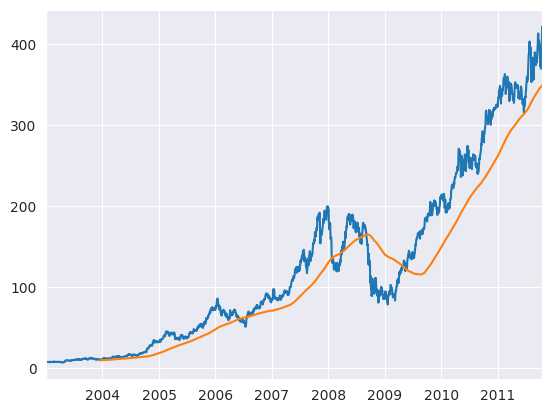

In [158]:
close_px["AAPL"].plot()
close_px["AAPL"].rolling(250).mean().plot();

A expressão `rolling(250)` tem um comportamento semelhante ao de `groupby`, mas, em vez de agrupar, cria um objeto que permite o agrupamento em uma janela deslizante de 250 dias. Assim, temos aqui a média móvel de `250` dias do preço das ações da Apple.

Por padrão, as funções de rolagem exigem que todos os valores na janela sejam diferentes de `NA`. Esse comportamento pode ser alterado para lidar com dados faltantes e, em particular, com o fato de que você terá menos períodos de dados do que o número de períodos da janela no início da série temporal.

In [159]:
import matplotlib.pyplot as plt
plt.figure();

<Figure size 640x480 with 0 Axes>

In [160]:
std250 = close_px["AAPL"].pct_change().rolling(250, min_periods=10).std()
std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.013818
Freq: B, Name: AAPL, dtype: float64

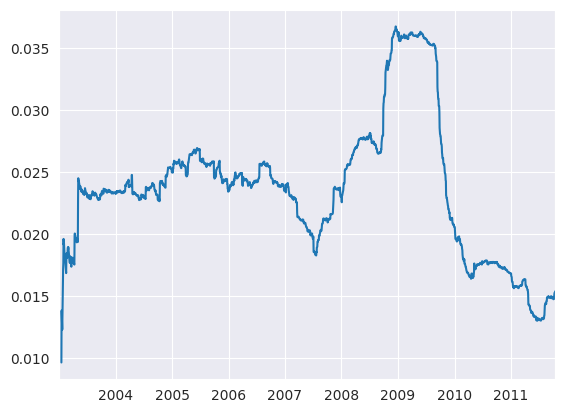

In [161]:
std250.plot();

Para calcular a média de uma janela expansiva, use o operador de expansão em vez do operador `rolling`. A média expansiva inicia a janela de tempo a partir do mesmo ponto que a janela de rolagem e aumenta o tamanho da janela até que ela abranja toda a série. Uma média de janela expansiva na série temporal `std250` se parece com isto:

In [162]:
expanding_mean = std250.expanding().mean()

Chamar uma função de janela deslizante em um `DataFrame` aplica a transformação a
cada coluna:

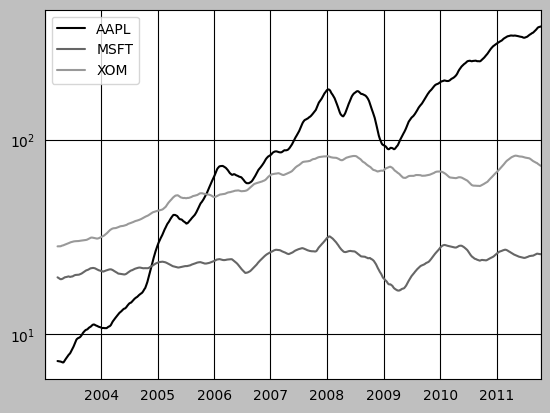

In [163]:
plt.style.use('grayscale')
close_px.rolling(60).mean().plot(logy=True);

A função `rolling` também aceita uma string indicando um deslocamento de tempo de tamanho fixo em funções de janela móvel, em vez de um número definido de períodos. Usar essa notação pode ser útil para séries temporais irregulares. Essas são as mesmas strings que você pode passar para a função `resample`. Por exemplo, poderíamos calcular uma média móvel de 20 dias da seguinte forma:

In [164]:
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


### 7.8.2. Funções Exponencialmente Ponderadas

Uma alternativa ao uso de um tamanho de janela fixo com observações igualmente ponderadas é especificar um fator de decaimento constante para dar mais peso às observações mais recentes. Existem algumas maneiras de especificar o fator de decaimento. Uma maneira popular é usar um intervalo (span), o que torna o resultado comparável a uma função de janela móvel simples com tamanho de janela igual ao intervalo.

Como uma estatística com ponderação exponencial atribui maior peso às observações mais recentes, ela se `"adapta"` mais rapidamente às mudanças em comparação com a versão com ponderação igual.

O Pandas possui o operador `ewm` (que significa média móvel exponencialmente ponderada) para complementar as médias móveis `rolling` e `expanding`. Aqui está um exemplo comparando a média móvel de 30 dias do preço das ações da Apple com uma média móvel exponencialmente ponderada (`EW`) com `span=60`:

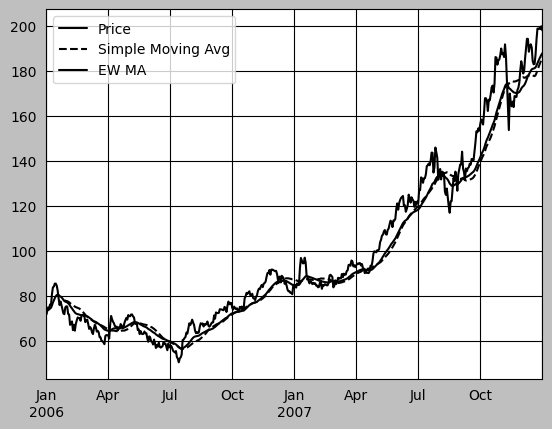

In [165]:
aapl_px = close_px["AAPL"]["2006":"2007"]
ma30 = aapl_px.rolling(30, min_periods=20).mean()
ewma30 = aapl_px.ewm(span=30).mean()
aapl_px.plot(style="k-", label="Price")
ma30.plot(style="k--", label="Simple Moving Avg")
ewma30.plot(style="k-", label="EW MA")
plt.legend();

### 7.8.3. Funções de Janela Móvel Binária

Algumas operações estatísticas, como correlação e covariância, precisam operar em duas séries temporais. Por exemplo, analistas financeiros frequentemente se interessam pela correlação de uma ação com um índice de referência como o `S&P 500`. Para analisar isso, primeiro calculamos:
a variação percentual para todas as nossas séries temporais de interesse:

In [166]:
spx_px = close_px_all["SPX"]
spx_rets = spx_px.pct_change()
returns = close_px.pct_change()

Após chamarmos a função `rolling`, a função de agregação `corr` pode então calcular a correlação de rolagem com `spx_rets`:

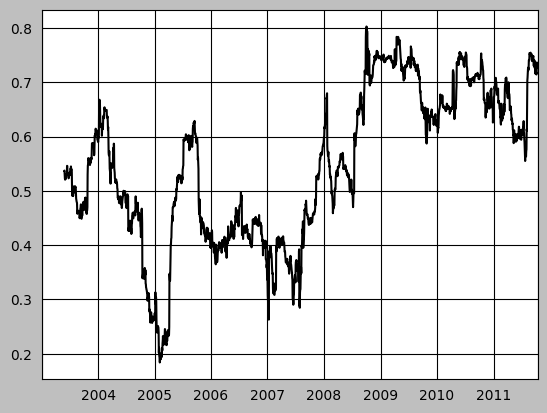

In [167]:
corr = returns["AAPL"].rolling(125, min_periods=100).corr(spx_rets)
corr.plot();

Suponha que você queira calcular a correlação móvel do índice `S&P 500` com várias ações simultaneamente. Você poderia escrever um loop calculando isso para cada ação, como fizemos para a Apple acima, mas se cada ação for uma coluna em um único `DataFrame`, podemos calcular todas as correlações móveis de uma só vez, chamando a função `rolling` no `DataFrame` e passando a `Series` `spx_rets`.

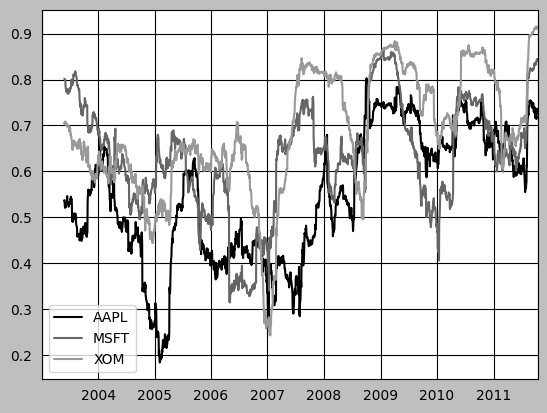

In [168]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
corr.plot();

### 7.8.4. Funções de Janela Móvel Definidas pelo Usuário

O método `apply` da classe `rolling` e métodos relacionados permitem aplicar uma função de matriz de sua própria criação a uma janela deslizante. O único requisito é que a função produza um único valor (uma redução) de cada elemento da matriz. Por exemplo, embora possamos calcular quantis amostrais usando `rolling(...).quantile(q)`, podemos estar interessados ​​na classificação percentil de um valor específico na amostra. A função `score_at_2percent` faz exatamente isso:

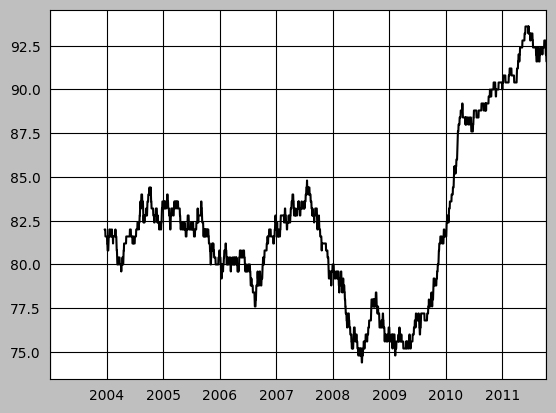

In [169]:
import pandas as pd
import numpy as np

def score_at_2percent(x):
    return (np.sum(x <= 0.02) / len(x)) * 100

result = returns["AAPL"].rolling(250).apply(score_at_2percent)
result.plot();

## 7.9. Exercícios

In [1]:
# Esta célula informa ao Jupyter para fornecer informações detalhadas de depuração
# quando ocorrer um erro de execução. Execute-o antes de trabalhar nos exercícios.

%xmode Verbose

Exception reporting mode: Verbose


A tabela abaixo tras detalhes sobre os dataset de Bug-Fixing do Apache Hadoop [labeled-hadoop-bug-fix-dataset.csv](./datasets/bugfix/labeled-hadoop-bug-fix-dataset.csv):

| Field                     | From | Type       | Description                                                                                       |
|---------------------------|------|------------|---------------------------------------------------------------------------------------------------|
| Project                   | Jira | General    | The project to which the bug belongs                                                              |
| Owner                     | Jira | General    | The owner/maintainer of the project                                                               |
| Manager                   | Jira | General    | The committee responsible for the project                                                         |
| Category                  | Jira | General    | The project domain category                                                                       |
| Key                       | Jira | General    | A unique identifier for the bug                                                                   |
| Priority                  | Jira | General    | The importance of the issue in relation to other issues.                                          |
| Status                    | Jira | General    | The stage the bug is currently at in its lifecycle                                                |
| Reporter                  | Jira | General    | The person who entered the bug into the system                                                    |
| Assignee                  | Jira | General    | The person who was assigned to fix the bug                                                        |
| Components                | Jira | General    | The project component(s) to which the bug relates                                                 |
| SummaryTopWords           | Jira | Text       | 1000 top most frequent words of a brief one-line summary of the bug                               |
| DescriptionTopWords       | Jira | Text       | 1000 top most frequent words of a detailed description of the bug                                 |
| CommentTopWords           | Jira | Text       | 1000 top most frequent words of the comments of the bug                                           |
| CreationDate              | Jira | Time       | The date and time on which the bug was entered into Jira                                          |
| ResolutionDate            | Jira | Time       | The date and time on which the bug was resolved                                                   |
| LastUpdateDate            | Jira | Time       | The date and time on which the bug report was updated for the last time                           |
| AffectsVersions           | Jira | Versioning | The project version(s) for which the bug is (or was) manifesting                                  |
| FixVersions               | Jira | Versioning | The project version(s) in which the bug was (or will be) fixed                                    |
| NoComments                | Jira | Summation  | The number of all comments added in the bug                                                       |
| FirstCommentDate          | Jira | Time       | The date and time on which the first comment was added in the bug report                          |
| LastCommentDate           | Jira | Time       | The date and time on which the last comment was added in the bug report                           |
| NoWatchers                | Jira | Summation  | The number of how many people are watching (interested in) the bug                                |
| NoAttachments             | Jira | Summation  | The number of attachments (documents, images, screenshots) added in the bug report                |
| FirstAttachmentDate       | Jira | Time       | The date and time on which the first attachment was added                                         |
| LastAttachmentDate        | Jira | Time       | The date and time on which the last attachment was added                                          |
| NoAttachedPatches         | Jira | Summation  | The number of patches added to the bug                                                            |
| FirstAttachedPatchDate    | Jira | Time       | The date and time on which the first patch was attached                                           |
| LastAttachedPatchDate     | Jira | Time       | The date and time on which the last patch was attached                                            |
| NoInwardIssueLinks        | Jira | Link       | The issue on which the bug depends on (type: inwardIssue).                                        |
| OutwardIssueLinks         | Jira | Link       | The issue that depends on the bug (type: outwardIssue).                                           |
| HasMergeCommit            | Git  | General    | This field informs whether a bug fix had or not a merge commit                                    |
| CommitsMessagesTopWords   | Git  | Text       | 1000 top most frequent words of the commit messages related to the bug                            |
| NoCommits                 | Git  | Summation  | The number of commits related to the bug                                                          |
| NoAuthors                 | Git  | Summation  | The number of different authors who performed commits related to the bug                          |
| NoCommitters              | Git  | Summation  | The number of different committers who performed commits related to the bug                       |
| AuthorsFirstCommitDate    | Git  | Time       | The date and time on which the author performed the first commit to fix the bug                   |
| AuthorsLastCommitDate     | Git  | Time       | The date and time on which the author performed the last commit to fix the bug                    |
| CommittersFirstCommitDate | Git  | Time       | The date and time on which the committer performed the first commit to fix the bug                |
| CommittersLastCommitDate  | Git  | Time       | The date and time on which the committer performed the last commit to fix the bug                 |
| NoSrcAddFiles             | Git  | SRC  | The number of ource code files added by commits related to the bug                           |
| NonSrcAddFiles            | Git  | SRC        | The number of non-source code files added by commits related to the bug                           |
| NonSrcDelFiles            | Git  | SRC        | The number of non-source code files deleted by commits related to the bug                         |
| NonSrcModFiles            | Git  | SRC        | The number of non-source code files modified by commits related to the bug                        |
| NonSrcAddLines            | Git  | SRC        | The number of non-source code lines added by commits related to the bug                           |
| NonSrcDelLines            | Git  | SRC        | The number of non-source code lines deleted by commits related to the bug                         |
| SrcAddFiles               | Git  | SRC        | The number of source code files added by commits related to the bug                               |
| SrcDelFiles               | Git  | SRC        | The number of source code files deleted by commits related to the bug                             |
| SrcModFiles               | Git  | SRC        | The number of source code files modified by commits related to the bug                            |
| SrcAddLines               | Git  | SRC        | The number of source code lines added by commits related to the bug                               |
| SrcDelLines               | Git  | SRC        | The number of deleted source code lines by commits related to the bug                             |
| TestAddFiles              | Git  | SRC        | The number of source code test files added by commits related to the bug                          |
| TestDelFiles              | Git  | SRC        | The number of source code test files deleted by commits related to the bug                        |
| TestModFiles              | Git  | SRC        | The number of source code test files modified by commits related to the bug                       |
| TestAddLines              | Git  | SRC        | The number of source code test lines added by commits related to the bug                          |
| TestDelLines              | Git  | SRC        | The number of source code test lines deleted by commits related to the bug                        |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pytz

# Carregar dataset
df = pd.read_csv(
    "/home/samuelmalves/Documents/Dev/Python/CTE-IA/prog-ciencia-de-dados/aulas/datasets/bugfix/labeled-hadoop-bug-fix-dataset.csv",
    sep=";",
    parse_dates=["CreationDate", "ResolutionDate", "FirstCommentDate", 
                 "LastCommentDate", "AuthorsFirstCommitDate", "AuthorsLastCommitDate"],
    low_memory=False
)

# Calcular tempo de resolução em dias
df["ResolutionTime"] = (df["ResolutionDate"] - df["CreationDate"]).dt.total_seconds() / 86400

print(f"Dataset carregado: {df.shape[0]} bugs")
df.head()

Dataset carregado: 4516 bugs


,Project,Owner,Manager,Category,Key,Priority,Status,Reporter,Assignee,Components,...,SrcModFiles,SrcAddLines,SrcDelLines,TestAddFiles,TestDelFiles,TestModFiles,TestAddLines,TestDelLines,Type,ResolutionTime
0,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4975,Major,Closed,jly,jly,NaN,...,0,0,0,0,0,0,0,0,0.0,21.432188
1,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4977,Blocker,Closed,matei,vivekr,NaN,...,0,0,0,0,0,0,0,0,0.0,12.152674
2,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4985,Major,Closed,szetszwo,szetszwo,NaN,...,0,0,0,0,0,0,0,0,1.0,5.797164
3,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4988,Blocker,Closed,vivekr,vivekr,NaN,...,0,0,0,0,0,0,0,0,0.0,8.542072
4,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4997,Blocker,Closed,rangadi,rangadi,NaN,...,0,0,0,0,0,0,0,0,0.0,8.149583


### 7.9.1. Exercício

**Criação e Indexação de Séries Temporais**

Objetivo: Criar uma série temporal indexada por `CreationDate` contando o número de bugs criados por dia.

Dicas:
1. Use `set_index()` para definir `CreationDate` como índice
2. Use `resample('D')` para agrupar por dia
3. Use `count()` para contar bugs por dia
4. Plotar os primeiros `100` dias

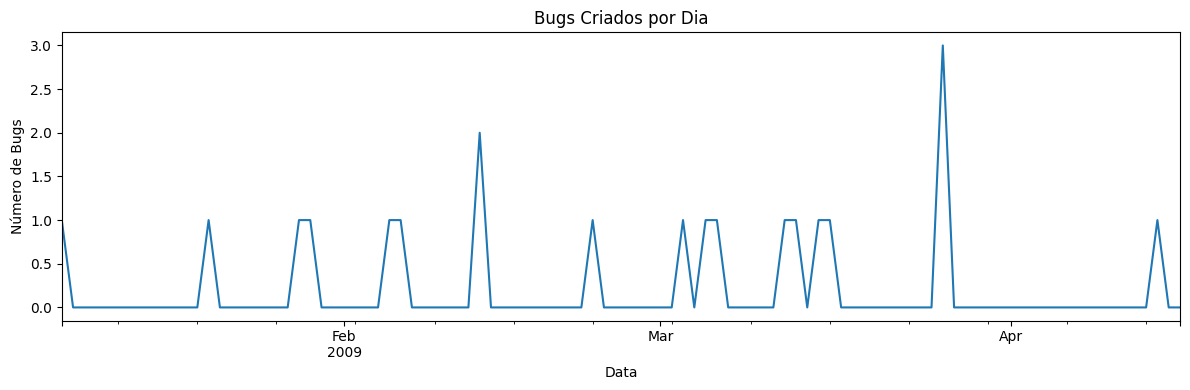

Dia com mais bugs criados: 2015-06-02 com 5 bugs


In [3]:
bugs = df[df["Type"] > 0.0]
ts_bugs_daily = bugs.set_index("CreationDate")["Key"].resample("D").count()

ts_bugs_daily.head(100).plot(title="Bugs Criados por Dia", figsize=(12, 4))
plt.ylabel("Número de Bugs")
plt.xlabel("Data")
plt.tight_layout()
plt.show()

print("Dia com mais bugs criados:", ts_bugs_daily.idxmax().date(), "com", ts_bugs_daily.max(), "bugs")

### 7.9.2. Exercício

**Trabalhando com date_range e Frequências**

Objetivo: Criar um índice de datas com diferentes frequências e explorar os bugs resolvidos em períodos específicos.

Dicas:

1. Use `pd.date_range()` para criar intervalos mensais de `2010` a `2020`
2. Conte quantos bugs foram resolvidos em cada mês (`ResolutionDate`)
3. Compare frequências: mensal (`ME`), trimestral (`Q-DEC`) e anual (`Y-DEC`)

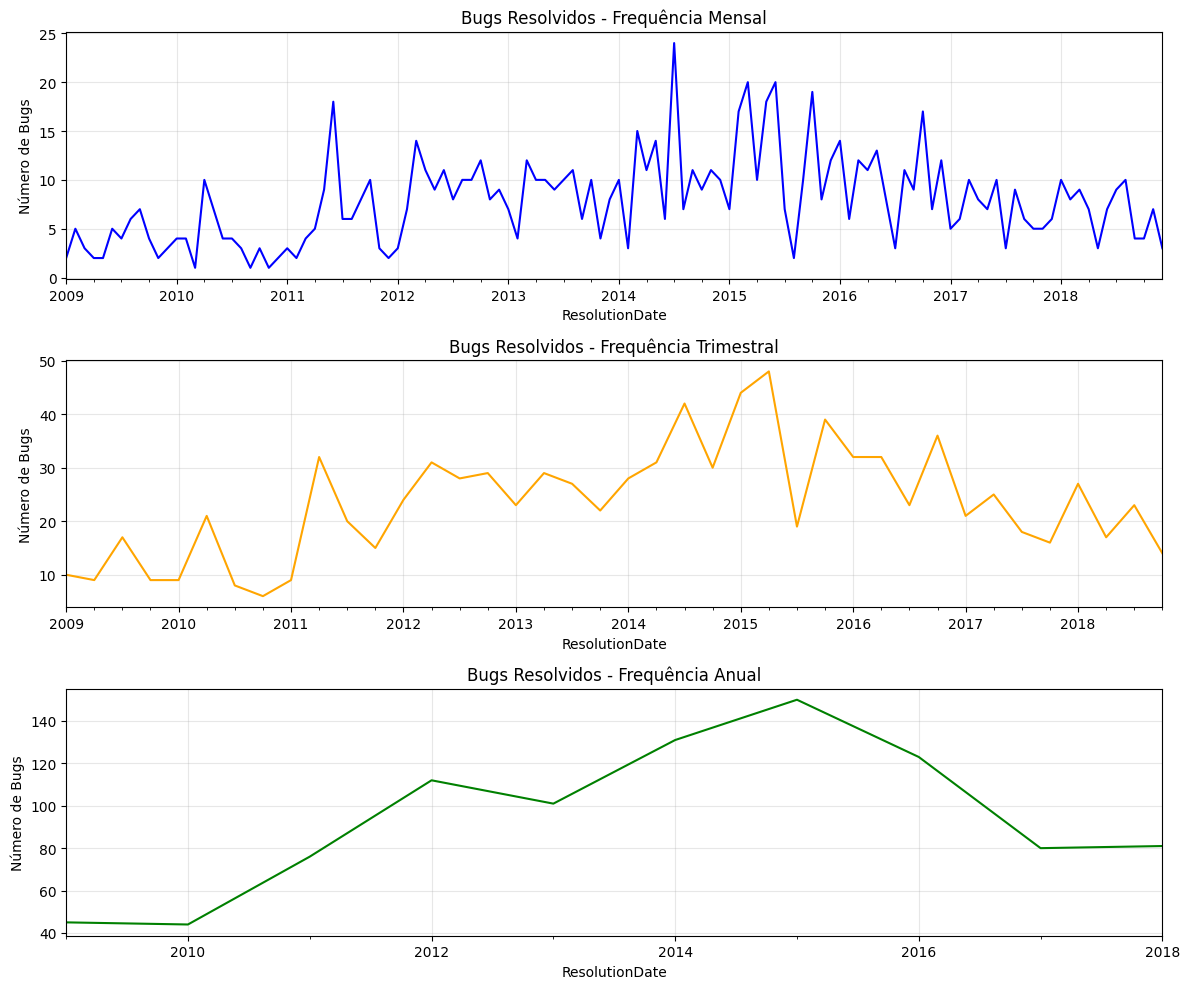

In [4]:
resolved_bugs = bugs[bugs["ResolutionDate"].notna()].set_index("ResolutionDate")["Key"].resample("D").count()

mensal = resolved_bugs.resample("ME").sum()
trimestral = resolved_bugs.resample("QE-DEC").sum()
anual = resolved_bugs.resample("YE-DEC").sum()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
mensal.plot(ax=axes[0], title="Bugs Resolvidos - Frequência Mensal", color="blue")
axes[0].set_ylabel("Número de Bugs")
axes[0].grid(True, alpha=0.3)

trimestral.plot(ax=axes[1], title="Bugs Resolvidos - Frequência Trimestral", color="orange")
axes[1].set_ylabel("Número de Bugs")
axes[1].grid(True, alpha=0.3)

anual.plot(ax=axes[2], title="Bugs Resolvidos - Frequência Anual", color="green")
axes[2].set_ylabel("Número de Bugs")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.9.3. Exercício

**Slicing e Seleção Temporal**

Objetivo: Selecionar e analisar bugs de períodos específicos usando diferentes métodos de indexação.

Dicas:

1. Selecione bugs criados apenas em `2015`
2. Selecione bugs do primeiro trimestre de `2016`
3. Selecione bugs entre `01/06/2017` e `31/12/2017`
4. Compare o número médio de comentários (`NoComments`) nesses períodos

In [5]:
ts_bugs = bugs.set_index("CreationDate").sort_index()

bugs_2015 = ts_bugs["2015" : "2016"]
bugs_q1_2016 = ts_bugs["2016-01" : "2016-03"]
bugs_h1_2017 = ts_bugs["2017-06" : "2017-12"]

print(f"Bugs criados em 2015: {len(bugs_2015)}")
print(f" Média de bugs criados em 2015: {bugs_2015['NoComments'].mean()}")
print(f" Mediana de bugs criados em 2015: {bugs_2015['NoComments'].median()}\n")

print(f"Bugs criados no primeiro trimestre de 2016: {len(bugs_q1_2016)}")
print(f" Média de bugs criados em 2016: {bugs_q1_2016['NoComments'].mean()}")
print(f" Mediana de bugs criados em 2016: {bugs_q1_2016['NoComments'].median()}\n")

print(f"Bugs criados no segundo semestre de 2017: {len(bugs_h1_2017)}")
print(f" Média de bugs criados em 2017: {bugs_h1_2017['NoComments'].mean()}")
print(f" Mediana de bugs criados em 2017: {bugs_h1_2017['NoComments'].median()}\n")


Bugs criados em 2015: 244
 Média de bugs criados em 2015: 22.81967213114754
 Mediana de bugs criados em 2015: 18.0

Bugs criados no primeiro trimestre de 2016: 30
 Média de bugs criados em 2016: 22.466666666666665
 Mediana de bugs criados em 2016: 18.5

Bugs criados no segundo semestre de 2017: 46
 Média de bugs criados em 2017: 16.891304347826086
 Mediana de bugs criados em 2017: 12.5



### 7.9.4. Exercício

**Conversão de Fusos Horários**

Objetivo: Trabalhar com fusos horários, assumindo que os timestamps estão em UTC e convertê-los para diferentes regiões.

Dicas:

1. Localize as datas para `UTC` usando `tz_localize()`
2. Converta para `America/New_York` e `Asia/Tokyo`
3. Analise a distribuição de bugs criados por hora do dia em cada fuso

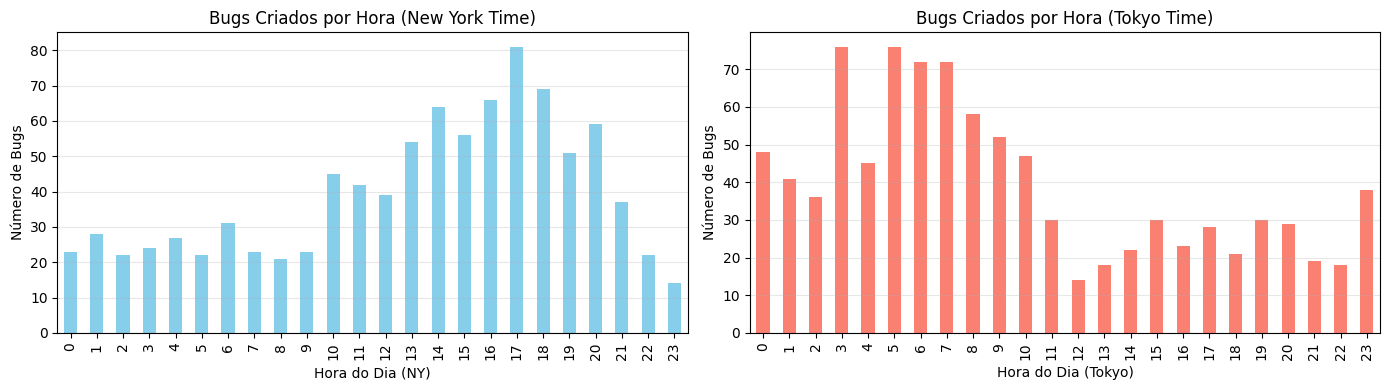

In [6]:
ts_bugs = bugs[["CreationDate", "Key"]].set_index("CreationDate").sort_index()


ts_bugs_utc = ts_bugs.tz_convert("UTC")
ts_bugs_ny = ts_bugs_utc.tz_convert("America/New_York")
ts_bugs_tokyo = ts_bugs_utc.tz_convert("Asia/Tokyo")

bugs_ny_hour_ny = ts_bugs_ny.groupby(ts_bugs_ny.index.hour)["Key"].count()
bugs_tokyo_hour_tokyo = ts_bugs_tokyo.groupby(ts_bugs_tokyo.index.hour)["Key"].count()

fi, axes = plt.subplots(1, 2, figsize=(14, 4))

bugs_ny_hour_ny.plot(kind="bar", ax=axes[0], color="skyblue", title="Bugs Criados por Hora (New York Time)")
axes[0].set_xlabel("Hora do Dia (NY)")
axes[0].set_ylabel("Número de Bugs")
axes[0].grid(True, alpha=0.3, axis='y')

bugs_tokyo_hour_tokyo.plot(kind="bar", ax=axes[1], color="salmon", title="Bugs Criados por Hora (Tokyo Time)")
axes[1].set_xlabel("Hora do Dia (Tokyo)")
axes[1].set_ylabel("Número de Bugs")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.9.5. Exercício

**Shifting e Cálculo de Variações**

Objetivo: Usar `shift()` para calcular variações consecutivas e identificar tendências na criação de bugs.

Dicas:

1. Conte bugs criados por semana
2. Use `shift()` para calcular a variação percentual semana a semana
3. Identifique as `5` semanas com maior aumento percentual


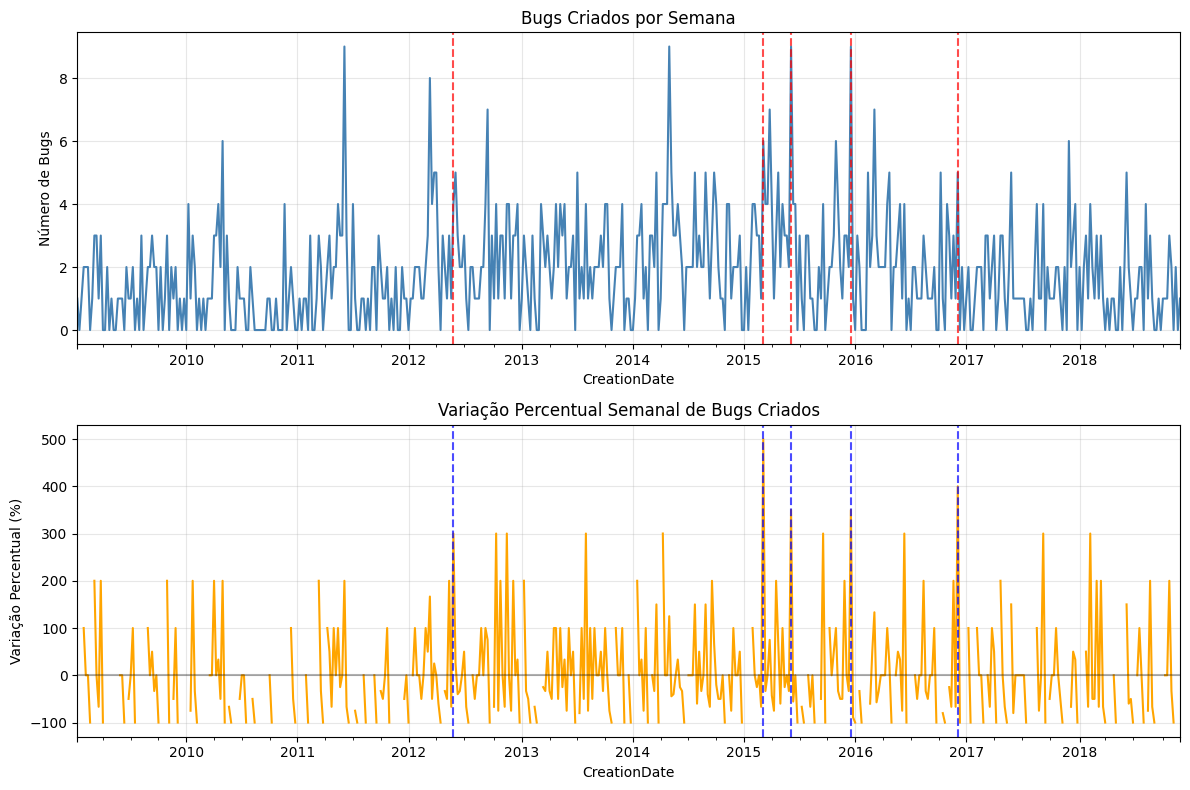

In [7]:
weekly_bugs = bugs.set_index("CreationDate")["Key"].resample("W").count()
pct_change = weekly_bugs.pct_change() * 100
top_increases = pct_change[pct_change.notna() & (pct_change != np.inf)].nlargest(5)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

weekly_bugs.plot(ax=axes[0], title="Bugs Criados por Semana", color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Número de Bugs")
axes[0].grid(True, alpha=0.3)

for date, change in top_increases.items():
    axes[0].axvline(x=date, color='red', linestyle='--', alpha=0.7)


pct_change.plot(ax=axes[1], title="Variação Percentual Semanal de Bugs Criados", color="orange", linewidth=1.5)
axes[1].set_ylabel("Variação Percentual (%)")
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].grid(True, alpha=0.3)

for date, change in top_increases.items():
    axes[1].axvline(x=date, color='blue', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 7.9.6. Exercício

**Trabalhando com Períodos**

Objetivo: Converter timestamps para períodos e analisar bugs por trimestre e ano fiscal.

Dicas:

1. Converta `CreationDate` para períodos trimestrais (`Q-DEC`)
2. Agrupe por período e calcule estatísticas (média de `ResolutionTime`, `NoCommits`)
3. Converta períodos para diferentes frequências (mensal, anual)

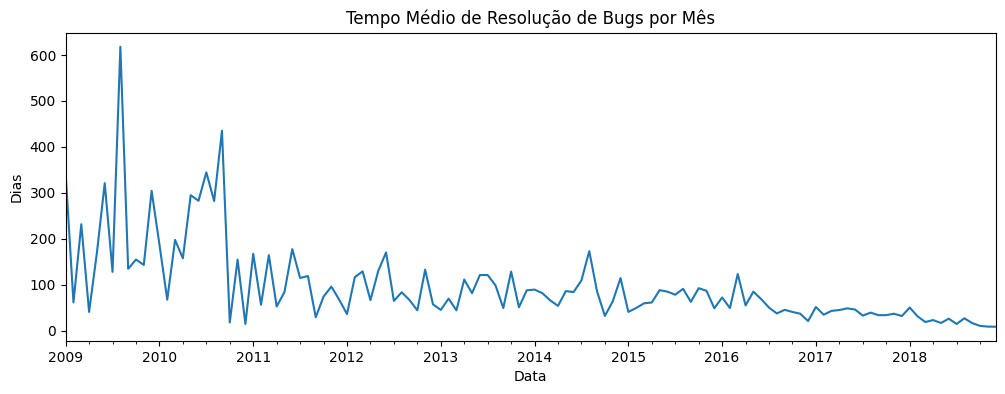

In [8]:
quarter_periods = df.set_index("CreationDate").groupby(pd.Grouper(freq="ME"))["ResolutionTime"].mean()
quarter_periods.plot(title="Tempo Médio de Resolução de Bugs por Mês", figsize=(12, 4))
plt.ylabel("Dias")
plt.xlabel("Data");

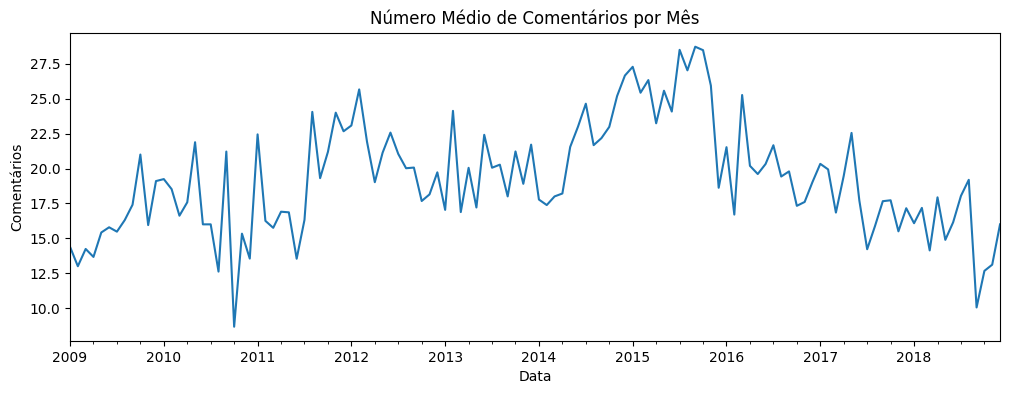

In [9]:
quarter_periods = df.set_index("CreationDate").groupby(pd.Grouper(freq="ME"))["NoComments"].mean()
quarter_periods.plot(title="Número Médio de Comentários por Mês", figsize=(12, 4))
plt.ylabel("Comentários")
plt.xlabel("Data");

### 7.9.7. Exercício

**Reamostragem (Downsampling)**

Objetivo: Aplicar downsampling para agregar bugs em diferentes frequências temporais.

Dicas:

1. Crie uma série temporal com múltiplas métricas (`NoComments`, `NoCommits`, `NoWatchers`)
2. Reamostre para frequência mensal calculando média, soma e máximo
3. Use diferentes regras de agregação para diferentes colunas

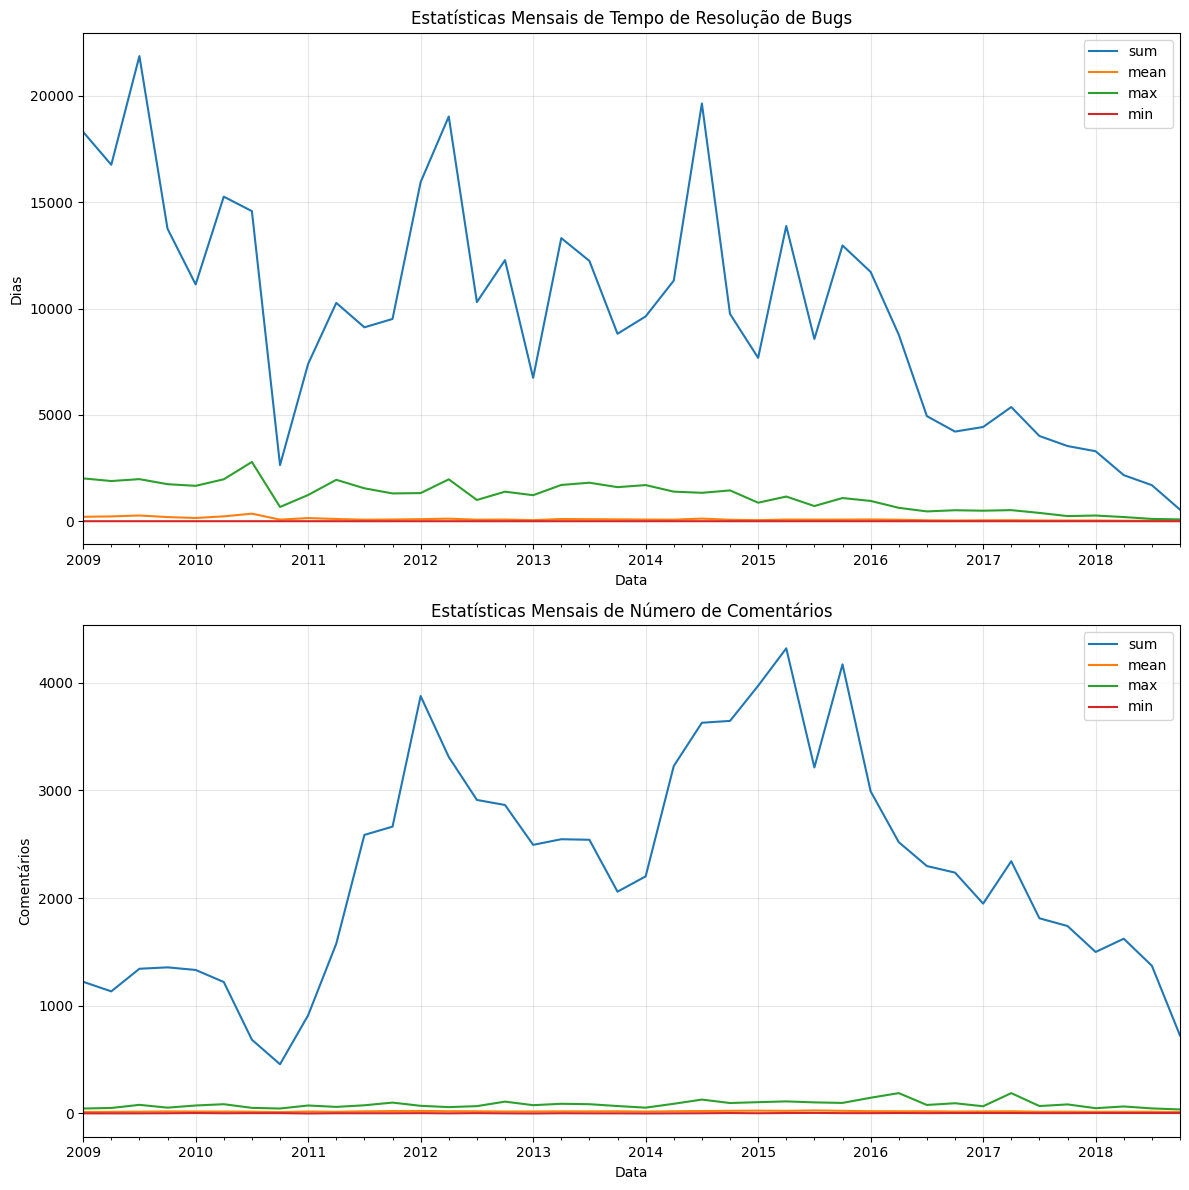

In [10]:
df_ts = df.set_index("CreationDate")[["ResolutionTime", "NoComments"]]

monthly_agg = df_ts.resample("QE-DEC").agg({"ResolutionTime": ["sum", "mean", "max", "min"],
                                        "NoComments": ["sum", "mean", "max", "min"]})

fig, axes = plt.subplots(2, 1, figsize=(12, 12))
monthly_agg["ResolutionTime"].plot(ax=axes[0], title="Estatísticas Mensais de Tempo de Resolução de Bugs")
axes[0].set_ylabel("Dias")
axes[0].set_xlabel("Data")
axes[0].grid(True, alpha=0.3)

monthly_agg["NoComments"].plot(ax=axes[1], title="Estatísticas Mensais de Número de Comentários")
axes[1].set_ylabel("Comentários")
axes[1].set_xlabel("Data")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.9.8. Exercício

**Reamostragem (Upsampling) e Interpolação**

Objetivo: Aplicar upsampling para preencher dados faltantes usando diferentes métodos de interpolação.

Dicas:

1. Crie série temporal mensal do tempo médio de resolução
2. Faça upsampling para frequência diária
3. Compare diferentes métodos: `ffill`, `bfill`, `interpolate` (linear)

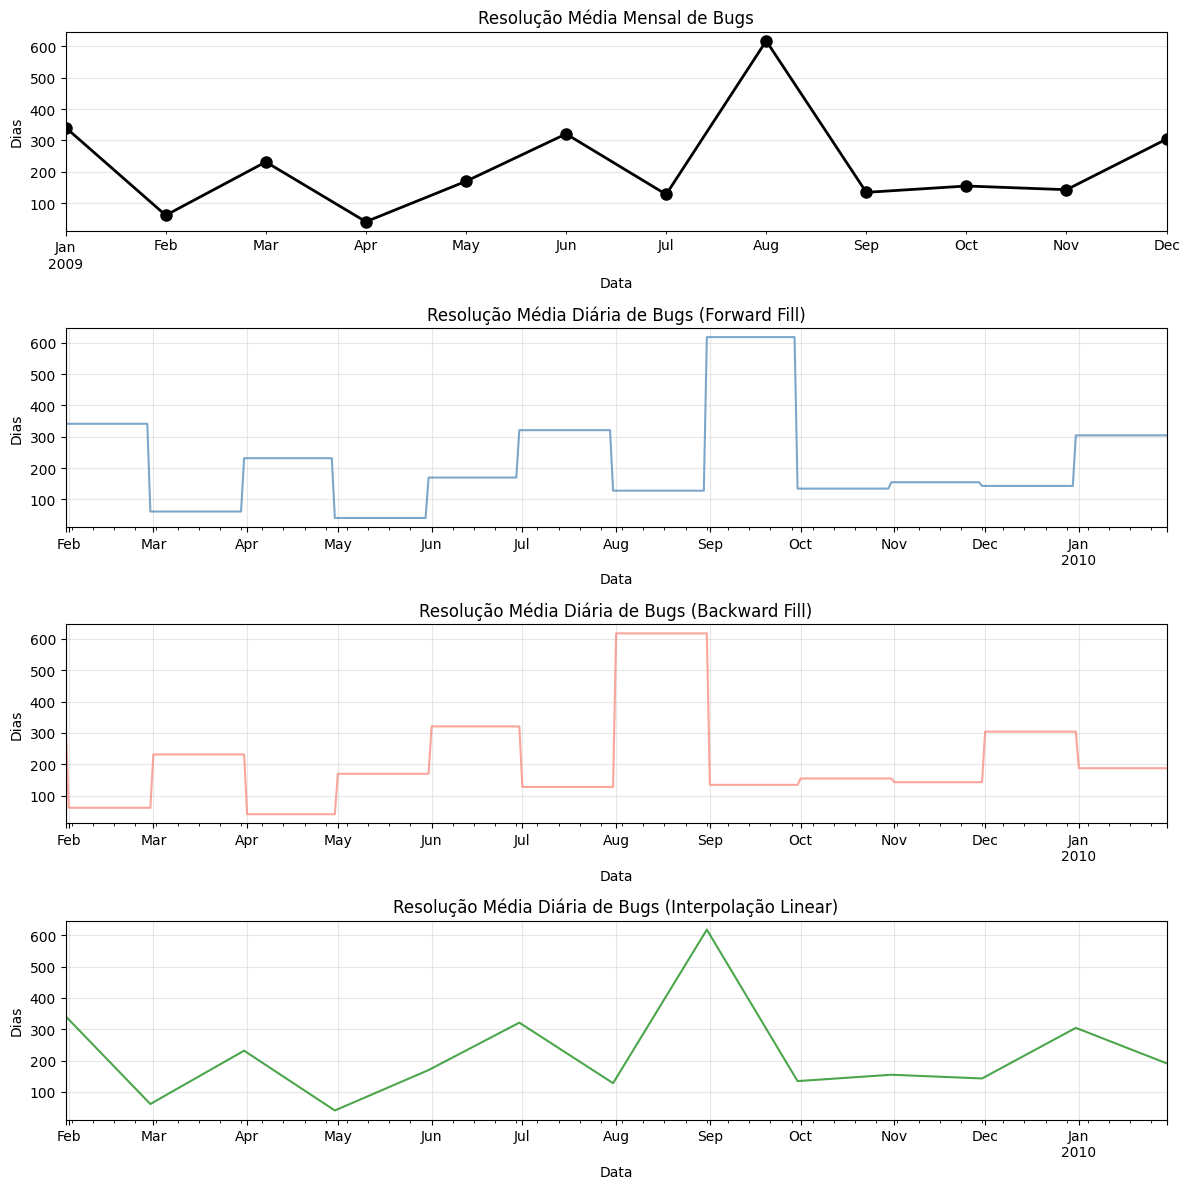

In [11]:
monthly_resulution = df.set_index("CreationDate")["ResolutionTime"].resample("ME").mean()

daily_ffill = monthly_resulution.resample("D").ffill()
daily_bfill = monthly_resulution.resample("D").bfill()
daily_interpolated = monthly_resulution.resample("D").interpolate(method="linear")

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

monthly_resulution.head(12).plot(ax=axes[0], marker="o", markersize=8, linewidth=2, 
                                 color="black", label="Original Mensal")
axes[0].set_title("Resolução Média Mensal de Bugs")
axes[0].set_ylabel("Dias")
axes[0].set_xlabel("Data")
axes[0].grid(True, alpha=0.3)

daily_ffill.head(365).plot(ax=axes[1], color="steelblue", alpha=0.7)
axes[1].set_title("Resolução Média Diária de Bugs (Forward Fill)")
axes[1].set_ylabel("Dias")
axes[1].set_xlabel("Data")
axes[1].grid(True, alpha=0.3)

daily_bfill.head(365).plot(ax=axes[2], color="salmon", alpha=0.7)
axes[2].set_title("Resolução Média Diária de Bugs (Backward Fill)")
axes[2].set_ylabel("Dias")
axes[2].set_xlabel("Data")
axes[2].grid(True, alpha=0.3)

daily_interpolated.head(365).plot(ax=axes[3], color="green", alpha=0.7)
axes[3].set_title("Resolução Média Diária de Bugs (Interpolação Linear)")
axes[3].set_ylabel("Dias")
axes[3].set_xlabel("Data")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 7.9.9. Exercício

**Funções de Janela Móvel (Rolling)**

Objetivo: Aplicar funções de janela móvel para suavizar dados e calcular médias móveis.

Dicas:

1. Calcule bugs criados por dia
2. Aplique média móvel de 7, 30 e 90 dias
3. Calcule desvio padrão móvel de 30 dias
4. Use `rolling().apply()` para criar função customizada (percentil `75`)

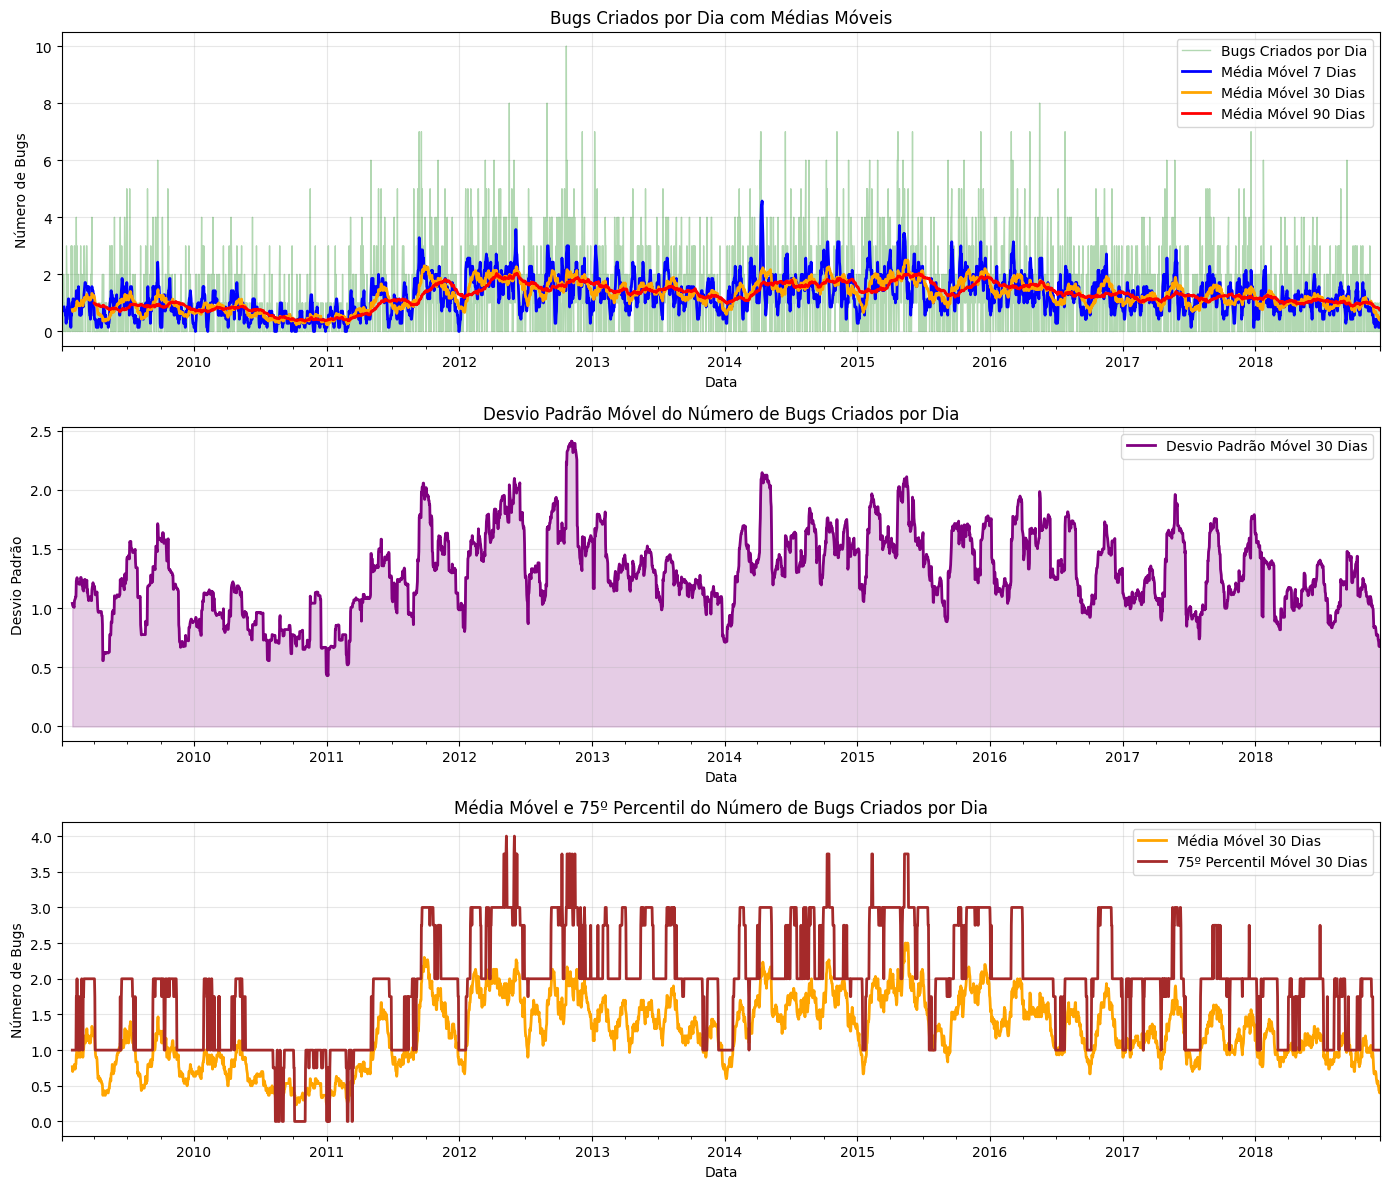

In [12]:
daily_bugs = df.set_index("CreationDate").resample("D")["Key"].count()

ma_7 = daily_bugs.rolling(window=7, center=False).mean()
ma_30 = daily_bugs.rolling(window=30, center=False).mean()
ma_90 = daily_bugs.rolling(window=90, center=False).mean()

std_30 = daily_bugs.rolling(window=30).std()

p75_30 = daily_bugs.rolling(window=30).apply(lambda x: np.percentile(x, 75), raw=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

daily_bugs.plot(ax=axes[0], alpha=0.3, color="green", label="Bugs Criados por Dia", linewidth=1)
ma_7.plot(ax=axes[0], color="blue", label="Média Móvel 7 Dias", linewidth=2)
ma_30.plot(ax=axes[0], color="orange", label="Média Móvel 30 Dias", linewidth=2)
ma_90.plot(ax=axes[0], color="red", label="Média Móvel 90 Dias", linewidth=2)
axes[0].set_title("Bugs Criados por Dia com Médias Móveis")
axes[0].set_ylabel("Número de Bugs")
axes[0].set_xlabel("Data")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

std_30.plot(ax=axes[1], color="purple", linewidth=2, label="Desvio Padrão Móvel 30 Dias")
axes[1].fill_between(std_30.index, 0, std_30.values, color="purple", alpha=0.2)
axes[1].set_title("Desvio Padrão Móvel do Número de Bugs Criados por Dia")
axes[1].set_ylabel("Desvio Padrão")
axes[1].set_xlabel("Data")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

ma_30.plot(ax=axes[2], color="orange", linewidth=2, label="Média Móvel 30 Dias")
p75_30.plot(ax=axes[2], color="brown", linewidth=2, label="75º Percentil Móvel 30 Dias")
axes[2].set_title("Média Móvel e 75º Percentil do Número de Bugs Criados por Dia")
axes[2].set_ylabel("Número de Bugs")
axes[2].set_xlabel("Data")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.9.10. Exercício

**Análise Temporal Avançada - Médias Ponderadas e Correlações Móveis**

Objetivo: Combinar conceitos avançados incluindo EWM (exponentially weighted moving average) e correlações móveis entre diferentes métricas.

Dicas:

1. Calcule série temporal de múltiplas métricas (`NoComments`, `NoCommits`, `ResolutionTime`)
2. Aplique EWM com span=30 para cada métrica
3. Calcule correlação móvel (90 dias) entre `NoComments` e `ResolutionTime`
4. Compare média simples vs. média ponderada exponencialmente

/home/samuelmalves/Documents/Dev/Python/CTE-IA/prog-ciencia-de-dados/prog-cd/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


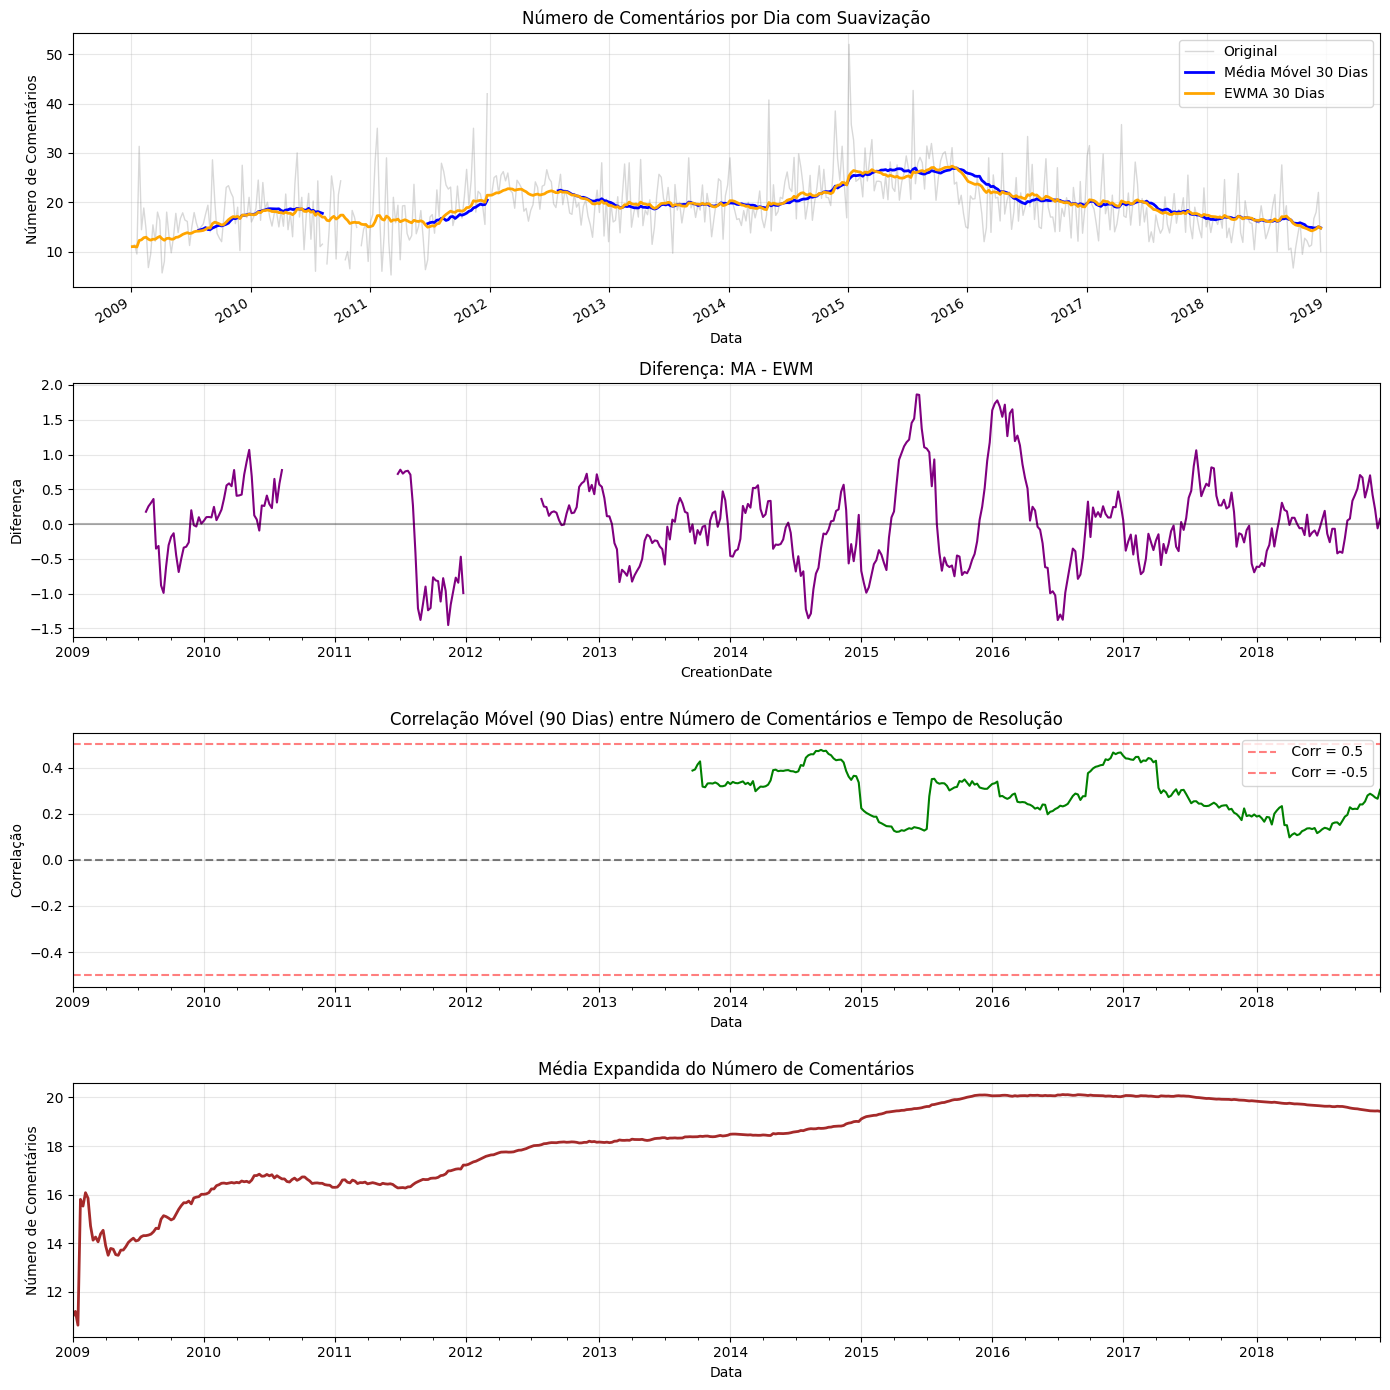

In [13]:
metrics = df.set_index("CreationDate")[["ResolutionTime", "NoComments", "NoCommits"]].resample("W").mean()

window_size = 30
comments_ma = metrics["NoComments"].rolling(window=window_size).mean()
comments_ewma = metrics["NoComments"].ewm(span=window_size, adjust=False).mean()

corr_window = 90
rolling_corr = (metrics["NoComments"].rolling(window=corr_window).corr(metrics["ResolutionTime"]))

comments_expanded = metrics["NoComments"].expanding().mean()

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

axes[0].plot(metrics.index, metrics["NoComments"], alpha=0.3, color="gray", label="Original", linewidth=1)
comments_ma.plot(ax=axes[0], color="blue", linewidth=2, label="Média Móvel 30 Dias")
comments_ewma.plot(ax=axes[0], color="orange", linewidth=2, label="EWMA 30 Dias")
axes[0].set_title("Número de Comentários por Dia com Suavização")
axes[0].set_ylabel("Número de Comentários")
axes[0].set_xlabel("Data")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

diff = comments_ma - comments_ewma
diff.plot(ax=axes[1], color='purple', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title("Diferença: MA - EWM")
axes[1].set_ylabel("Diferença")
axes[1].grid(True, alpha=0.3)

rolling_corr.plot(ax=axes[2], color='green', linewidth=1.5)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5);
axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label=" Corr = 0.5")
axes[2].axhline(y=-0.5, color='red', linestyle='--', alpha=0.5, label=" Corr = -0.5")
axes[2].fill_between(rolling_corr.index, 0, rolling_corr.values, 
                     where=(rolling_corr.abs() > 0.5), 
                     color="green", alpha=0.1)
axes[2].set_title("Correlação Móvel (90 Dias) entre Número de Comentários e Tempo de Resolução")
axes[2].set_ylabel("Correlação")
axes[2].set_xlabel("Data")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

comments_expanded.plot(ax=axes[3], color='brown', linewidth=2)
axes[3].set_title("Média Expandida do Número de Comentários")
axes[3].set_ylabel("Número de Comentários")
axes[3].set_xlabel("Data")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()